# Table of Contents

1. Pulling the Data](
1. Preparing the Data
1. Further Cleaning

# Pulling the Data

All of the data collected from others was collected

In [1]:
# !pip install gspread pandas google-auth
import gspread
from google.oauth2.service_account import Credentials
import os, pandas as pd
from pathlib import Path


/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
os.environ["GOOGLE_SHEETS_CREDENTIALS"] = (
    "/opt/notebooks/psalms_nlp_sp26/private/psalms-blind-scoring-da42a38adf3c.json"
)

os.getcwd()

'/opt/notebooks/psalms_nlp_sp26/query_compare'

In [3]:
# Current notebook directory
notebook_dir = Path.cwd()

# Build path to the JSON
cred_path = notebook_dir.parent / "private" / "psalms-blind-scoring-da42a38adf3c.json"
print("Credential path exists?", cred_path.exists())

os.getcwd()

Credential path exists? True


'/opt/notebooks/psalms_nlp_sp26/query_compare'

In [4]:
import socket
socket.gethostbyname("oauth2.googleapis.com")


'192.178.155.95'

In [5]:
creds = Credentials.from_service_account_file(
    os.environ["GOOGLE_SHEETS_CREDENTIALS"],
    scopes=[
        "https://www.googleapis.com/auth/spreadsheets",
        "https://www.googleapis.com/auth/drive"
    ]
)

client = gspread.authorize(creds)

sheet = client.open("results_scored")

In [6]:
# Access second sheet (index 1)
worksheet2 = sheet.get_worksheet(1)

# Get all values
data = worksheet2.get_all_values()

# Convert to DataFrame (first row as header)
df = pd.DataFrame(data[1:], columns=data[0])

# storing the collected data for reference later
df.to_csv("../data/results_scored.csv", index=False, mode="w")


In [7]:
df

,Query,Method,Similarity Score (%),Text,Psalm Num,Verse,CadenScore,Score1,User1,Score2,User2,Score3,User3,,
0,Create in me a clean heart,TFIDF_GLoVe,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,9,5,p06,1,p03,3,p08,,
1,Create in me a clean heart,TFIDF_GLoVe,25.67,Bible,4,For the End in psalms an ode by David You hear...,6,1,p03,8,p04,7,p06,,
2,Create in me a clean heart,TFIDF_GLoVe,21.90,Bible,31,By David concerning understanding Blessed are ...,3,7,p06,1,p03,3,p10,,
3,Create in me a clean heart,TFIDF_GLoVe,18.33,Psalter,31,Blessed are they whose iniquities are forgiven...,10,7,p06,6,p05,5,p09,,
4,Create in me a clean heart,TFIDF_GLoVe,18.12,Bible,61,For the End for Jeduthun a psalm by David Shal...,7,2,p01,0,p03,2,p08,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,,,,,,,,,,,,,,,
237,,,,,,,,,,,,,,,
238,,,,,,,,,,,,,,,
239,,,,,,,,,,,,,,,


In [9]:
for query in df["Query"].unique():
    print(query)

Create in me a clean heart
For the Peace of the world
Have mercy on me, O God, have mercy on me. For my soul trusts in Thee, and in the shadow of Thy wings will I hope, until iniquity pass away.
How does the psalmist express trust in God while surrounded by fear and uncertainty?
mercy
praise in times of suffering
prayer
protection from enemies
Rejoice, O ye heavens, sound the trumpets, ye foundation of the earth, thunder forth gladness, O ye mountains: for behold, Emmanuel to the Cross our sins, and the Giver of Life hath slain death, raising up Adam; for He loveth mankind.
The Lord is my shepherd
Verses where the psalmist remembers past deliverance and uses it to find hope in present trials.



# Preparing the data
I want each row to hold one of the four possible scored for each of the `236 results`. So if rebuilt properly, we should end up with a total of: 
$$236 * 4 = 944\ results$$

I need to start by unpivoting my own score separte from the other scores.

## Numbering the Results 
I also want to be able to reference the order of the results within each search. I collected the top 5 results from each search. There was a bug in my code that took the top 6 results from searches. I am going to just worry about the top 5 results to keep everything fair. 

In [9]:
# temporary dataframe to not break the original 
temp = df.copy()

# aqdding a column to number the indivudal results
temp['numbered_result'] = pd.NA
#temp

In [10]:
n = temp.shape[0]

num_result = 1
query = temp.loc[temp.index[0], "Query"]
method = temp.loc[temp.index[0], "Method"]

for i in range(n):
    if query == temp.loc[temp.index[i], "Query"] and \
       method == temp.loc[temp.index[i], "Method"]:
        
        temp.loc[temp.index[i], "numbered_result"] = num_result
        num_result += 1
        
    else:
        temp.loc[temp.index[i], "numbered_result"] = 1
        num_result = 2
        query = temp.loc[temp.index[i], "Query"]
        method = temp.loc[temp.index[i], "Method"]


In [11]:
# select first 7 columns + last column
cols_to_keep = list(temp.columns[:7]) + [temp.columns[-1]]
caden = temp[cols_to_keep]

# caden.head()


In [12]:
caden['User'] = 'caden'

caden = caden.rename(columns={"CadenScore": "Score"})

# caden

/tmp/ipykernel_733/2631933811.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  caden['User'] = 'caden'


In [13]:
caden  = caden[['Query', 'Method', "numbered_result", 'Similarity Score (%)', 'Text', 'Psalm Num', 'Verse', 'User', 'Score']]
caden

,Query,Method,numbered_result,Similarity Score (%),Text,Psalm Num,Verse,User,Score
0,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,caden,9
1,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...,caden,6
2,Create in me a clean heart,TFIDF_GLoVe,3,21.90,Bible,31,By David concerning understanding Blessed are ...,caden,3
3,Create in me a clean heart,TFIDF_GLoVe,4,18.33,Psalter,31,Blessed are they whose iniquities are forgiven...,caden,10
4,Create in me a clean heart,TFIDF_GLoVe,5,18.12,Bible,61,For the End for Jeduthun a psalm by David Shal...,caden,7
...,...,...,...,...,...,...,...,...,...
236,,,1,,,,,caden,
237,,,2,,,,,caden,
238,,,3,,,,,caden,
239,,,4,,,,,caden,


Moving on to prepaering the external scores.

In [14]:
external = temp[['Query', 'Method', "numbered_result", 'Similarity Score (%)', 'Text', 'Psalm Num', 'Verse', 'User1', 'Score1', 'User2', 'Score2', 'User3', 'Score3']]

#external

In [15]:
# Unpivot User/Score pairs
df_long = pd.wide_to_long(
    external,
    stubnames=["User", "Score"],  # the base column names
    i=["Query", "Method", "numbered_result", "Similarity Score (%)", "Text", "Psalm Num", "Verse"],  # columns to keep
    j="Pair",  # new column for the pair number
    sep=""      # number comes directly after the stub name
).reset_index()

# Optional: reorder columns
df_long = df_long[["Query", "Method", "numbered_result",  "Similarity Score (%)", "Text", "Psalm Num", "Verse", "Pair", "User", "Score"]]



In [16]:
external = df_long[["Query", "Method", "numbered_result",  "Similarity Score (%)", "Text", "Psalm Num", "Verse", "User", "Score"]]

external

,Query,Method,numbered_result,Similarity Score (%),Text,Psalm Num,Verse,User,Score
0,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,p06,5
1,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,p03,1
2,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,p08,3
3,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...,p03,1
4,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...,p04,8
...,...,...,...,...,...,...,...,...,...
718,,,4,,,,,,
719,,,4,,,,,,
720,,,5,,,,,,5.199152542
721,,,5,,,,,,5.398305085


In [17]:
#caden.head()

## Combining the Prepared Data back together

In [18]:
scores = pd.concat([caden, external], ignore_index=True)
scores

,Query,Method,numbered_result,Similarity Score (%),Text,Psalm Num,Verse,User,Score
0,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,caden,9
1,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...,caden,6
2,Create in me a clean heart,TFIDF_GLoVe,3,21.90,Bible,31,By David concerning understanding Blessed are ...,caden,3
3,Create in me a clean heart,TFIDF_GLoVe,4,18.33,Psalter,31,Blessed are they whose iniquities are forgiven...,caden,10
4,Create in me a clean heart,TFIDF_GLoVe,5,18.12,Bible,61,For the End for Jeduthun a psalm by David Shal...,caden,7
...,...,...,...,...,...,...,...,...,...
959,,,4,,,,,,
960,,,4,,,,,,
961,,,5,,,,,,5.199152542
962,,,5,,,,,,5.398305085


In [19]:
(scores["Score"].notna() & (scores["Score"] != "")).sum()

948

In [20]:
#scores["Query"].unique()

We now have our intended 944 rows of data we can move on to do last few preperations for the analysis. 

# Further Data Cleaning <a href="further_cleaning"></a>

I now need to work on some of the anaiysis of the data and alot of the imediate processiong was done within another notebook so it will be coppied into here. 

## Query Categoization

In [21]:
query_categories = {
    "mercy": "Simple Keyword Queries",
    "prayer":"Simple Keyword Queries",
    "The Lord is my shepherd": "Phrase/Exact Match Queries",
    "Create in me a clean heart":"Phrase/Exact Match Queries",
    "protection from enemies": "Thematic/Semantic Queries",
    "praise in times of suffering": "Thematic/Semantic Queries",
    "How does the psalmist express trust in God while surrounded by fear and uncertainty?":
        "Long/Complex Queries",
    "Verses where the psalmist remembers past deliverance and uses it to find hope in present trials.":
        "Long/Complex Queries",
    "Rejoice, O ye heavens, sound the trumpets, ye foundation of the earth, thunder forth gladness, O ye mountains: for behold, Emanuel to the Cross our sins, and the Giver of Life hath slain death, raising up Adam; for He loveth mankind.":
        "Orthodox Service Quotes",
    "Have mercy on me, O God, have mercy on me. For my soul trusts in Thee, and in the shadow of Thy wings will I hope, until iniquity pass away.":
        "Orthodox Service Quotes",
    "For the Peace of the world": "Orthodox Service Quotes"

}

In [22]:
scores["Query Category"] = scores["Query"].map(query_categories)
#scores

In [23]:
# reordering the columns of the dataframe
scores = scores [["Query", "Query Category", "Method", "numbered_result", "Similarity Score (%)", "Text", "Psalm Num", 
                  "Verse", "User", "Score" ]]

#scores

In [24]:
# reordering the columns of the dataframe
scores = scores [["Query", "Query Category", "Method","Similarity Score (%)", "numbered_result",
                  "Text", "Psalm Num", "Verse", "User", "Score" ]]

#scores

In [25]:
# filtering to only be studying the top 5 results from each query
scores = scores[scores['numbered_result'] != 6]


pd.set_option("display.max_rows", 50)

#scores[scores['Method'] == 'TFIDF']

In [26]:
external = external[external['numbered_result'] != 6]

In [27]:
external

,Query,Method,numbered_result,Similarity Score (%),Text,Psalm Num,Verse,User,Score
0,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,p06,5
1,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,p03,1
2,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,p08,3
3,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...,p03,1
4,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...,p04,8
...,...,...,...,...,...,...,...,...,...
718,,,4,,,,,,
719,,,4,,,,,,
720,,,5,,,,,,5.199152542
721,,,5,,,,,,5.398305085


In [28]:
scores.columns

Index(['Query', 'Query Category', 'Method', 'Similarity Score (%)',
       'numbered_result', 'Text', 'Psalm Num', 'Verse', 'User', 'Score'],
      dtype='object')

In [29]:
scores["Score"] = pd.to_numeric(scores["Score"], errors="coerce")

avg = scores.groupby("User")["Score"].agg(["mean", "count"])

avg["mean"] = avg["mean"].round(2)
avg["count"] = avg["count"].astype(int)

avg

,mean,count
User,,
,5.32,3
caden,5.99,216
p01,5.04,94
p02,5.74,31
p03,3.24,95
p04,6.56,27
p05,8.33,85
p06,4.35,103
p07,6.27,22


---

# Analysis

## Inner-Annotator Agreement
Every person that contributed to the scoring of the results aproached them differently even though the same intetion was behind each score conceived. Each result of the *236 results*, was scored up to three times. This may cause discrepency in how each result was scored overall. **Inner-Anotator Agreement** works at trying to normalize the differeint in scored overall, and for each indivual result. 
There are a few different metricsx that handel this. The data for this study is ordinal which means that a `1` is closer to `2` than `5`, making this just just a category. For this reason **Krippendorff's** alpha agreement is what's going to be used. 

The overall metric consists of the following equation:
$$
\alpha = 1 - \frac{D_0}{D_e}
$$

Where $D_0$ is:
$$
D_o = \frac{1}{n} \sum_{c} \sum_{k} o_{ck} \, \delta_{ck}^2
$$

And $D_e$ is:
$$
D_e = \frac{1}{n(n-1)} \sum_{c} \sum_{n_c} n_c * n_{k\ ordinal} \, \delta_{ck}^2
$$

In [30]:
import pandas as pd
import numpy as np

Code for: $$D_o = \frac{1}{n} \sum_{c} \sum_{k} o_{ck} \, \delta_{ck}^2$$

In [31]:
import numpy as np

o_ck = [[0.0]*11 for _ in range(11)]
pairable_n = 0

o_ck

[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]

Building the $o_ck$ portion of $D_0$:

In [32]:
pairable_n = 0

# coincidence matrix (0–10 scale)
o_ck = [[0.0]*11 for _ in range(11)]

# marginal frequencies n_c
counts = [0]*11

In [33]:
def process_row_external(row):

    scores = [row['Score1'], row['Score2'], row['Score3']]

    valid_scores = []
    for s in scores:
        if not pd.isna(s) and s != "":
            val = int(float(s))
            valid_scores.append(val)
            counts[val] += 1   # <-- THIS is how you get counts

    m_u = len(valid_scores)

    if m_u < 2:
        return

    global pairable_n
    pairable_n += m_u

    for i in range(m_u):
        for j in range(m_u):
            if i == j:
                continue
            c = valid_scores[i]
            k = valid_scores[j]
            o_ck[c][k] += 1/(m_u-1)

In [34]:
for _, row in df.iterrows():
    process_row_external(row)

print(counts)

[54, 85, 59, 53, 42, 59, 57, 49, 88, 81, 84]


<div style=" padding:10px; display:inline-block;">
$$
\delta^2_{ck} = \left( \sum_{g=c}^{\max(c,g)} n_g - \frac{n_c + n_k}{2} \right)^2
$$
</div>

In [35]:
def ordinal_delta_sq(c, k):
    if c == k:
        return 0.0
    
    low = min(c, k)
    high = max(c, k)

    # cumulative counts between ranks
    cumu = sum(counts[g] for g in range(low, high+1))

    # subtract half endpoints
    cumu -= (counts[c] + counts[k]) / 2

    return cumu ** 2

In [36]:
def compute_D_o():
    total_coincidences = sum(sum(row) for row in o_ck)
    if total_coincidences == 0:
        return None  # or 0

    total = 0
    for c in range(len(o_ck)):
        for k in range(len(o_ck)):
            delta_sq = ordinal_delta_sq(c, k)
            total += o_ck[c][k] * delta_sq

    return total / total_coincidences

In [37]:
pairable_n = 0
o_ck = [[0.0]*11 for _ in range(11)]
counts = [0]*11  # important if using ordinal_delta_sq

for idx, row in df.iterrows():
    process_row_external(row)

D_o = compute_D_o()

D_o

57626.3417721519

    d_0(temp.iloc[0]
### Building the Coincidences Matrix

In [38]:
o_ck

[[10.0, 9.5, 8.0, 4.5, 2.5, 3.0, 5.0, 3.5, 3.5, 4.5, 0.0],
 [9.5, 10.0, 10.0, 5.5, 6.0, 6.0, 5.0, 6.5, 14.5, 8.0, 4.0],
 [8.0, 10.0, 7.0, 6.5, 3.5, 5.0, 3.5, 4.5, 4.0, 4.0, 3.0],
 [4.5, 5.5, 6.5, 3.0, 5.0, 4.5, 6.5, 3.5, 7.0, 4.0, 3.0],
 [2.5, 6.0, 3.5, 5.0, 1.0, 7.0, 4.0, 2.0, 5.5, 3.0, 2.5],
 [3.0, 6.0, 5.0, 4.5, 7.0, 8.0, 4.5, 5.0, 5.0, 6.0, 5.0],
 [5.0, 5.0, 3.5, 6.5, 4.0, 4.5, 4.0, 5.0, 7.0, 7.5, 5.0],
 [3.5, 6.5, 4.5, 3.5, 2.0, 5.0, 5.0, 6.0, 2.0, 4.5, 6.5],
 [3.5, 14.5, 4.0, 7.0, 5.5, 5.0, 7.0, 2.0, 11.0, 11.5, 17.0],
 [4.5, 8.0, 4.0, 4.0, 3.0, 6.0, 7.5, 4.5, 11.5, 14.0, 14.0],
 [0.0, 4.0, 3.0, 3.0, 2.5, 5.0, 5.0, 6.5, 17.0, 14.0, 24.0]]

### $D_e$
Code for: $D_e = \frac{1}{n(n-1)} \sum_{c} \sum_{n_c} n_c * n_{k\ metric} \, \delta_{ck}^2$

*Where*:
> - $n_c$ = number of times score `c` occurs in the dataset  
> - $n_k$ = number of times score `k` occurs in the dataset  
> - $\delta_{ck}^2$ = squared distance between scores `c` and `k`  
> - `n(n-1)` = total number of pairs in the dataset

Code for 
$$
D_e = \frac{\sum_c \sum_k n_c n_k \left( \sum_{g=\min(c,k)}^{\max(c,k)} n_g - \frac{n_c + n_k}{2} \right)^2}{n(n-1)}, 
\quad n = \sum_c n_c
$$

In [39]:
def compute_D_e():

    n = sum(counts)

    total = 0
    for c in range(11):
        for k in range(11):
            delta_sq = ordinal_delta_sq(c, k)
            total += counts[c] * counts[k] * delta_sq

    return total / (n*(n-1))

Now we can refer to the original formula: $\alpha = 1 - \frac{D_0}{D_e}$

In [40]:
def alpha():
    d_o = compute_D_o()
    d_e = compute_D_e()
    print("D_e = " + str(d_e))
    return 1 - (d_o / d_e)

In [41]:
external.head()

,Query,Method,numbered_result,Similarity Score (%),Text,Psalm Num,Verse,User,Score
0,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,p06,5
1,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,p03,1
2,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,p08,3
3,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...,p03,1
4,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...,p04,8


In [42]:
alpha()

D_e = 83547.33802816902


0.31025520223370295

- `02/20/2026`- $\alpha = 0.614410708025859$
    - I was not properly computing $D_e$ correctly. I was using $(c-k)^2$ rather than $\delta^2_{ck}$. The code above represents the ordinal computations.
- `02/21/2026`- $\alpha = 0.9999895570896626$
Debugging

## Testing with the offical python package


Confirming my results with the offical pacakge before going further. 

In [43]:
# %pip install krippendorff
import krippendorff

In [44]:
import numpy as np
import pandas as pd

temp = df

cols_without = ['Score1', 'Score2', 'Score3']
cols_with = ['CadenScore', 'Score1', 'Score2', 'Score3']

temp[cols_without] = temp[cols_without].apply(pd.to_numeric, errors='coerce')
temp[cols_with] = temp[cols_with].apply(pd.to_numeric, errors='coerce')

In [45]:
data_without_caden = temp[['Score1', 'Score2', 'Score3']].T.to_numpy()

alpha_without = krippendorff.alpha(
    reliability_data=data_without_caden,
    level_of_measurement='ordinal'
)

print("Without Caden:", alpha_without)

Without Caden: 0.3101853865785704


# Rebuilding

Resuilding the metric computation to re compute the score to be able to compute quickly for specfric sets of the data. 

In [46]:
def build_coincidence_matrix(df, score_columns, max_score=10):

    counts = [0]*(max_score+1)
    o_ck = np.zeros((max_score+1, max_score+1))
    pairable_n = 0

    for _, row in df.iterrows():
        scores = [row[col] for col in score_columns]
        
        valid_scores = []
        for s in scores:
            if not pd.isna(s) and s != "":
                val = int(float(s))
                valid_scores.append(val)
                counts[val] += 1

        m_u = len(valid_scores)
        if m_u < 2:
            continue

        pairable_n += m_u

        for i in range(m_u):
            for j in range(m_u):
                if i == j:
                    continue
                c = valid_scores[i]
                k = valid_scores[j]
                o_ck[c][k] += 1/(m_u-1)

    return counts, o_ck, pairable_n

In [47]:
def ordinal_delta_sq(c, k, counts):
    if c == k:
        return 0.0

    low = min(c, k)
    high = max(c, k)

    cumu = sum(counts[g] for g in range(low, high+1))
    cumu -= (counts[c] + counts[k]) / 2

    return cumu ** 2

In [48]:
def compute_D_o(o_ck, counts, max_score=10):

    total_coincidences = o_ck.sum()
    if total_coincidences == 0:
        return None

    total = 0
    for c in range(max_score+1):
        for k in range(max_score+1):
            delta_sq = ordinal_delta_sq(c, k, counts)
            total += o_ck[c][k] * delta_sq

    return total / total_coincidences

In [49]:
def compute_D_e(counts, max_score=10):

    n_total = sum(counts)
    if n_total < 2:
        return None

    total = 0
    for c in range(max_score+1):
        for k in range(max_score+1):
            delta_sq = ordinal_delta_sq(c, k, counts)
            total += counts[c] * counts[k] * delta_sq

    return total / (n_total * (n_total - 1))

In [50]:
def compute_alpha(D_o, D_e):

    if D_o is None or D_e is None:
        return None

    if D_e == 0:
        return 1.0

    return 1 - (D_o / D_e)

In [51]:
def krippendorff_alpha_ordinal(df, score_columns, max_score=10):

    counts, o_ck, pairable_n = build_coincidence_matrix(
        df, score_columns, max_score
    )

    D_o = compute_D_o(o_ck, counts, max_score)
    D_e = compute_D_e(counts, max_score)

    alpha = compute_alpha(D_o, D_e)

    return alpha #, D_o, D_e, counts, o_ck

With these functions built, I want to veriofy they are working the way they did before. 

In [52]:
krippendorff_alpha_ordinal(df, ['Score1', 'Score2', 'Score3'], max_score=10)

0.31025520223370295

We are getting the same score a before. This is an easier way of applying the metic because it is easier to change what data to compute. Lets. work on trying different parts of the data. 

### Adding my score

In [53]:
krippendorff_alpha_ordinal(df, ['CadenScore', 'Score1', 'Score2', 'Score3'], max_score=10)

0.27848095437886256

### Looking at each indivual Algorithm
#### TFIDF

In [54]:
temp = df[df['Method'] == 'TFIDF']

print("Witout Caden: ",
      (krippendorff_alpha_ordinal(temp, ['Score1', 'Score2', 'Score3'], max_score=10)))


print("With Caden: ", 
      (krippendorff_alpha_ordinal(temp, ['CadenScore', 'Score1', 'Score2', 'Score3'], max_score=10)))


Witout Caden:  0.33723629326246785
With Caden:  0.2697702321936132


#### TFIDF x GLoVE

In [55]:
temp = df[df['Method'] == 'TFIDF_GLoVe']

print("Witout Caden: ",
      (krippendorff_alpha_ordinal(temp, ['Score1', 'Score2', 'Score3'], max_score=10)))


print("With Caden: ", 
      (krippendorff_alpha_ordinal(temp, ['CadenScore', 'Score1', 'Score2', 'Score3'], max_score=10)))


Witout Caden:  0.42123841220762215
With Caden:  0.39983513136824533


#### BERT

In [56]:
temp = df[df['Method'] == 'BERT']

print("Witout Caden: ",
      (krippendorff_alpha_ordinal(temp, ['Score1', 'Score2', 'Score3'], max_score=10)))


print("With Caden: ", 
      (krippendorff_alpha_ordinal(temp, ['CadenScore', 'Score1', 'Score2', 'Score3'], max_score=10)))


Witout Caden:  0.21552672364327075
With Caden:  0.1823935555819125


#### SBERT

In [57]:
temp = df[df['Method'] == 'SBERT']

print("Witout Caden: ",
      (krippendorff_alpha_ordinal(temp, ['Score1', 'Score2', 'Score3'], max_score=10)))


print("With Caden: ", 
      (krippendorff_alpha_ordinal(temp, ['CadenScore', 'Score1', 'Score2', 'Score3'], max_score=10)))


Witout Caden:  0.22086359690187518
With Caden:  0.19530330813764396


## Investigating the Low Alpha Score

The overall `Krippendorff Aplpha` score I calculated was
$$\alpha_{w/out\ Caden} = 0.3132363233535458$$
and 
$$\alpha_{w/ \ Caden} = 0.27457889178612493$$

These tell us that the scores between everyone is not reliable, Lets see what might be contributing to that. 

### Looking at the everage score of each user

In [58]:
caden

,Query,Method,numbered_result,Similarity Score (%),Text,Psalm Num,Verse,User,Score
0,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,caden,9
1,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...,caden,6
2,Create in me a clean heart,TFIDF_GLoVe,3,21.90,Bible,31,By David concerning understanding Blessed are ...,caden,3
3,Create in me a clean heart,TFIDF_GLoVe,4,18.33,Psalter,31,Blessed are they whose iniquities are forgiven...,caden,10
4,Create in me a clean heart,TFIDF_GLoVe,5,18.12,Bible,61,For the End for Jeduthun a psalm by David Shal...,caden,7
...,...,...,...,...,...,...,...,...,...
236,,,1,,,,,caden,
237,,,2,,,,,caden,
238,,,3,,,,,caden,
239,,,4,,,,,caden,


In [59]:
import pandas as pd

# Convert 'Score' to numeric, invalid parsing becomes NaN
scores['Score'] = pd.to_numeric(scores['Score'], errors='coerce')

# Optional: drop rows where conversion failed
scores = scores.dropna(subset=['Score'])

# Finally, convert to integer
scores['Score'] = scores['Score'].astype(int)

scores['Score'].count()

864

In [60]:
scores.pivot_table(index='User', values='Score', aggfunc=['mean', 'count'])

,mean,count
,Score,Score
User,,
,5.000000,3
caden,5.986111,216
p01,5.042553,94
p02,5.741935,31
p03,3.242105,95
p04,6.555556,27
p05,8.329412,85
p06,4.349515,103


In [61]:
scores['Score'].mean()

5.427083333333333

In [62]:
import numpy as np

def score_category(score):
    # If score is missing or not a number, return np.nan
    if pd.isna(score) or score == '':
        return np.nan
    # Otherwise convert to float and categorize
    score = float(score)
    if score <= 3:
        return 1  # Low
    elif score <= 7:
        return 2  # Medium
    else:
        return 3  # High

In [63]:
df['Score_Caden Category'] = df['CadenScore'].apply(score_category)

df['Score_1 Category'] = df['Score1'].apply(score_category)
df['Score_2 Category'] = df['Score2'].apply(score_category)
df['Score_3 Category'] = df['Score3'].apply(score_category)

In [64]:
df.head()

,Query,Method,Similarity Score (%),Text,Psalm Num,Verse,CadenScore,Score1,User1,Score2,User2,Score3,User3,,,Score_Caden Category,Score_1 Category,Score_2 Category,Score_3 Category
0,Create in me a clean heart,TFIDF_GLoVe,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,9.0,5.0,p06,1.0,p03,3.0,p08,,,3.0,2.0,1.0,1.0
1,Create in me a clean heart,TFIDF_GLoVe,25.67,Bible,4,For the End in psalms an ode by David You hear...,6.0,1.0,p03,8.0,p04,7.0,p06,,,2.0,1.0,3.0,2.0
2,Create in me a clean heart,TFIDF_GLoVe,21.90,Bible,31,By David concerning understanding Blessed are ...,3.0,7.0,p06,1.0,p03,3.0,p10,,,1.0,2.0,1.0,1.0
3,Create in me a clean heart,TFIDF_GLoVe,18.33,Psalter,31,Blessed are they whose iniquities are forgiven...,10.0,7.0,p06,6.0,p05,5.0,p09,,,3.0,2.0,2.0,2.0
4,Create in me a clean heart,TFIDF_GLoVe,18.12,Bible,61,For the End for Jeduthun a psalm by David Shal...,7.0,2.0,p01,0.0,p03,2.0,p08,,,2.0,1.0,1.0,1.0


### Using Krippendorff ALpha for categorical scores

In [65]:
print(df.columns.tolist())

['Query', 'Method', 'Similarity Score (%)', 'Text', 'Psalm Num', 'Verse', 'CadenScore', 'Score1', 'User1', 'Score2', 'User2', 'Score3', 'User3', '', '', 'Score_Caden Category', 'Score_1 Category', 'Score_2 Category', 'Score_3 Category']


In [66]:
df

,Query,Method,Similarity Score (%),Text,Psalm Num,Verse,CadenScore,Score1,User1,Score2,User2,Score3,User3,,,Score_Caden Category,Score_1 Category,Score_2 Category,Score_3 Category
0,Create in me a clean heart,TFIDF_GLoVe,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,9.000000,5.000000,p06,1.000000,p03,3.000000,p08,,,3.0,2.0,1.0,1.0
1,Create in me a clean heart,TFIDF_GLoVe,25.67,Bible,4,For the End in psalms an ode by David You hear...,6.000000,1.000000,p03,8.000000,p04,7.000000,p06,,,2.0,1.0,3.0,2.0
2,Create in me a clean heart,TFIDF_GLoVe,21.90,Bible,31,By David concerning understanding Blessed are ...,3.000000,7.000000,p06,1.000000,p03,3.000000,p10,,,1.0,2.0,1.0,1.0
3,Create in me a clean heart,TFIDF_GLoVe,18.33,Psalter,31,Blessed are they whose iniquities are forgiven...,10.000000,7.000000,p06,6.000000,p05,5.000000,p09,,,3.0,2.0,2.0,2.0
4,Create in me a clean heart,TFIDF_GLoVe,18.12,Bible,61,For the End for Jeduthun a psalm by David Shal...,7.000000,2.000000,p01,0.000000,p03,2.000000,p08,,,2.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,,,,,,,NaN,NaN,,NaN,,NaN,,,,NaN,NaN,NaN,NaN
237,,,,,,,NaN,NaN,,NaN,,NaN,,,,NaN,NaN,NaN,NaN
238,,,,,,,NaN,NaN,,NaN,,NaN,,,,NaN,NaN,NaN,NaN
239,,,,,,,NaN,NaN,,NaN,,NaN,,,,NaN,NaN,NaN,NaN


In [67]:
# Step 2: Convert to numpy array
data_without_caden = df[['Score_1 Category','Score_2 Category','Score_3 Category']].T.to_numpy()

# Step 3: Compute Krippendorff (with missing values preserved)
alpha_without = krippendorff.alpha(
    reliability_data=data_without_caden,
    level_of_measurement='ordinal'
)

print("Without Caden:", alpha_without)

Without Caden: 0.2650403334570296


From a different studying Using `Krippendorff's alpha`: 

**"A Validated Scoring Rubric for Explain-in-Plain-English Questions" <br>**
> "we first applied z-score standardization on a per question basis to account for the variations in question difficulty. After standardization, we computed the average z-score for each student to account for the fact that some students answered fewer code reading questions. "
>
- There is variation in every rater's view of the Psalms in addition to the different interpretations of each query
- No one was given an example of this because it up to interpretation as everyone is seeking the Psalsm with different prespectives, as I make note of within the introduction of the Poster and Paper. 
- Applying the `Z-score` standarization may help in these realistic short comings. 

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

$$
\mu_j = \frac{1}{n} \sum_{i=1}^{n} x_{ij}
$$

$$
\sigma_j = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_{ij} - \mu_j)^2}
$$

After the z-score is implented the data turns into interval data

In [68]:
# Keep only numeric scores
raters = ['CadenScore', 'Score1', 'Score2', 'Score3']

# Z-score standardization (per rater)
df_z = (df[raters] - df[raters].mean()) / df[raters].std()

# Convert to numpy for Krippendorff
import krippendorff
data = df_z.T.to_numpy()

alpha = krippendorff.alpha(reliability_data=data, level_of_measurement='ordinal')

print("Krippendorff alpha (z-score standardized):", alpha)

Krippendorff alpha (z-score standardized): 0.2850750378398855


In [69]:
# Keep only numeric scores
raters = ['Score1', 'Score2', 'Score3']

# Z-score standardization (per rater)
df_z = (df[raters] - df[raters].mean()) / df[raters].std()

# Convert to numpy for Krippendorff
import krippendorff
data = df_z.T.to_numpy()

alpha = krippendorff.alpha(reliability_data=data, level_of_measurement='ordinal')

print("Krippendorff alpha (z-score standardized):", alpha)

Krippendorff alpha (z-score standardized): 0.30737625130972834


Krippendorff’s alpha (ordinal) looks at how raters rank or differentiate items relative to each other.

If raters disagree on the ordering of items, subtracting each rater’s mean doesn’t help — it only shifts the scores up or down.

---

In [70]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

temp = df[df['Method'] == 'TFIDF_GLoVe']

def weighted_kappa_average(dataframe, columns):

    kappas = []

    for i in range(len(columns)):
        for j in range(i+1, len(columns)):

            r1 = dataframe[columns[i]]
            r2 = dataframe[columns[j]]

            # Remove missing values
            valid = ~(r1.isna() | r2.isna())

            kappa = cohen_kappa_score(
                r1[valid],
                r2[valid],
                weights='quadratic'
            )

            kappas.append(kappa)

    return np.mean(kappas)

In [71]:
scores.head()

,Query,Query Category,Method,Similarity Score (%),numbered_result,Text,Psalm Num,Verse,User,Score
0,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,26.10,1,Psalter,100,I will sing of mercy and judgment unto Thee O ...,caden,9
1,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,25.67,2,Bible,4,For the End in psalms an ode by David You hear...,caden,6
2,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,21.90,3,Bible,31,By David concerning understanding Blessed are ...,caden,3
3,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.33,4,Psalter,31,Blessed are they whose iniquities are forgiven...,caden,10
4,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.12,5,Bible,61,For the End for Jeduthun a psalm by David Shal...,caden,7


In [72]:
pd.pivot_table(data=scores, index=['User', "Method"], values='Score', aggfunc = 'count')

Score
User  Method            
                       3
caden                  1
      BERT            55
      SBERT           55
      TFIDF           50
...                  ...
p16   SBERT            4
      TFIDF            2
      TFIDF_GLoVe      1
p17   TFIDF            1
      TFIDF_GLoVe      3

[56 rows x 1 columns]

In [73]:

scores

,Query,Query Category,Method,Similarity Score (%),numbered_result,Text,Psalm Num,Verse,User,Score
0,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,26.10,1,Psalter,100,I will sing of mercy and judgment unto Thee O ...,caden,9
1,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,25.67,2,Bible,4,For the End in psalms an ode by David You hear...,caden,6
2,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,21.90,3,Bible,31,By David concerning understanding Blessed are ...,caden,3
3,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.33,4,Psalter,31,Blessed are they whose iniquities are forgiven...,caden,10
4,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.12,5,Bible,61,For the End for Jeduthun a psalm by David Shal...,caden,7
...,...,...,...,...,...,...,...,...,...,...
944,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,5.61,5,Psalter,35,"The transgressor, that he may sin, saith withi...",p05,7
945,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,5.61,5,Psalter,35,"The transgressor, that he may sin, saith withi...",p06,2
961,,NaN,,,5,,,,,5
962,,NaN,,,5,,,,,5


In [74]:
print(scores.columns.tolist())

['Query', 'Query Category', 'Method', 'Similarity Score (%)', 'numbered_result', 'Text', 'Psalm Num', 'Verse', 'User', 'Score']


In [75]:
scores_piv = scores.pivot_table(
    index=['Query', 'Query Category', 'Method', 'Similarity Score (%)', 'numbered_result', 'Text', 'Psalm Num', 'Verse'],  # or whatever defines a unique row
    columns="User",
    values="Score",
    aggfunc="first"
).reset_index()

In [76]:
scores_piv

User,Query,Query Category,Method,Similarity Score (%),numbered_result,Text,Psalm Num,Verse,caden,p01,...,p04,p05,p06,p07,p08,p09,p10,p13,p16,p17
0,Create in me a clean heart,Phrase/Exact Match Queries,BERT,68.31,5,Bible,147,Alleluia of Aggeus and Zacharias Praise the Lo...,5.0,NaN,...,NaN,6.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,Create in me a clean heart,Phrase/Exact Match Queries,BERT,68.66,4,Psalter,43,"We have heard with our ears, O God, for our fa...",0.0,3.0,...,NaN,7.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Create in me a clean heart,Phrase/Exact Match Queries,BERT,68.69,3,Psalter,49,"The God of gods, even the Lord, hath spoken, a...",5.0,NaN,...,NaN,9.0,7.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN
3,Create in me a clean heart,Phrase/Exact Match Queries,BERT,69.06,2,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",8.0,NaN,...,NaN,NaN,5.0,NaN,7.0,NaN,4.0,NaN,NaN,NaN
4,Create in me a clean heart,Phrase/Exact Match Queries,BERT,69.89,1,Bible,18,For the End a psalm by David The heavens decla...,4.0,NaN,...,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,18.97,5,Bible,151,1This is a psalm written with Davids own hand ...,6.0,5.0,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,22.61,4,Psalter,28,"Bring unto the Lord, O ye sons of God, bring u...",3.0,NaN,...,NaN,NaN,1.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
192,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,23.85,3,Psalter,86,His foundations are in the holy mountains. The...,4.0,NaN,...,5.0,NaN,0.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
193,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,25.01,2,Bible,28,A psalm by David the final day of the Feast of...,9.0,3.0,...,NaN,NaN,0.0,NaN,8.0,NaN,NaN,NaN,NaN,NaN


In [77]:
# Count how many scores each user has
counts = scores_piv.count()

# Keep users with 125 or more scores
pivoted = scores_piv.loc[:, counts >= 15]

pivoted

User,Query,Query Category,Method,Similarity Score (%),numbered_result,Text,Psalm Num,Verse,caden,p01,p02,p03,p04,p05,p06,p07,p08,p09,p10,p13
0,Create in me a clean heart,Phrase/Exact Match Queries,BERT,68.31,5,Bible,147,Alleluia of Aggeus and Zacharias Praise the Lo...,5.0,NaN,NaN,0.0,NaN,6.0,NaN,NaN,NaN,NaN,0.0,NaN
1,Create in me a clean heart,Phrase/Exact Match Queries,BERT,68.66,4,Psalter,43,"We have heard with our ears, O God, for our fa...",0.0,3.0,NaN,NaN,NaN,7.0,5.0,NaN,NaN,NaN,NaN,NaN
2,Create in me a clean heart,Phrase/Exact Match Queries,BERT,68.69,3,Psalter,49,"The God of gods, even the Lord, hath spoken, a...",5.0,NaN,NaN,NaN,NaN,9.0,7.0,NaN,NaN,NaN,NaN,10.0
3,Create in me a clean heart,Phrase/Exact Match Queries,BERT,69.06,2,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",8.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,7.0,NaN,4.0,NaN
4,Create in me a clean heart,Phrase/Exact Match Queries,BERT,69.89,1,Bible,18,For the End a psalm by David The heavens decla...,4.0,NaN,8.0,1.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,18.97,5,Bible,151,1This is a psalm written with Davids own hand ...,6.0,5.0,9.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
191,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,22.61,4,Psalter,28,"Bring unto the Lord, O ye sons of God, bring u...",3.0,NaN,NaN,NaN,NaN,NaN,1.0,7.0,7.0,NaN,NaN,NaN
192,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,23.85,3,Psalter,86,His foundations are in the holy mountains. The...,4.0,NaN,NaN,NaN,5.0,NaN,0.0,NaN,5.0,NaN,NaN,NaN
193,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,25.01,2,Bible,28,A psalm by David the final day of the Feast of...,9.0,3.0,NaN,NaN,NaN,NaN,0.0,NaN,8.0,NaN,NaN,NaN


In [78]:
raters = scores_piv.columns.difference([
    'Query',
    'Query Category',
    'Method',
    'Similarity Score (%)',
    'numbered_result',
    'Text',
    'Psalm Num',
    'Verse'
])

df_raters = scores_piv[raters]

In [79]:
avg = df_raters.agg(['mean', 'count']).T
avg['mean'] = avg['mean'].round(2)
avg

,mean,count
User,,
caden,5.93,195.0
p01,5.00,87.0
p02,5.56,27.0
p03,3.28,86.0
p04,6.42,26.0
p05,8.30,76.0
p06,4.53,89.0
p07,6.48,21.0
p08,6.20,54.0


In [80]:
data = df_raters.to_numpy().T

data

array([[ 5.,  0.,  5., ...,  4.,  9., 10.],
       [nan,  3., nan, ..., nan,  3., nan],
       [nan, nan, nan, ..., nan, nan, 10.],
       ...,
       [nan, nan, 10., ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [81]:
import pandas as pd
import krippendorff

def compute_krippendorff(df_raters, users_to_include, 
                         min_ratings_per_item=2, level='ordinal', zscore=False):
    """
    Compute Krippendorff alpha for a subset of raters, optionally z-score standardizing.

    Parameters:
    -----------
    df_raters : pd.DataFrame
        DataFrame with raters as columns and items as rows
    users_to_include : list of str
        List of rater column names to include
    min_ratings_per_item : int
        Minimum number of non-missing ratings per item to keep
    level : str
        Level of measurement ('ordinal', 'interval', etc.)
    zscore : bool
        If True, standardize each rater's scores using z-score

    Returns:
    --------
    alpha : float
        Krippendorff alpha value
    df_clean : pd.DataFrame
        Filtered DataFrame used to compute alpha
    included_users : list
        List of users actually included
    """

    # Keep only users that exist in the DataFrame
    included_users = [u for u in users_to_include if u in df_raters.columns]
    if not included_users:
        raise ValueError("No valid users to include in df_raters.")

    # Subset the DataFrame
    df_subset = df_raters[included_users].copy()

    # Apply z-score per rater if requested
    if zscore:
        df_subset = (df_subset - df_subset.mean()) / df_subset.std(ddof=0)

    # Keep only rows/items with enough ratings
    df_clean = df_subset[df_subset.notna().sum(axis=1) >= min_ratings_per_item]

    # Convert to raters × items numpy array
    data = df_clean.to_numpy().T

    # Compute Krippendorff alpha
    alpha = krippendorff.alpha(reliability_data=data, level_of_measurement=level)

    return alpha, df_clean, included_users

In [82]:
df_raters

User,caden,p01,p02,p03,p04,p05,p06,p07,p08,p09,p10,p13,p16,p17
0,5.0,NaN,NaN,0.0,NaN,6.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,0.0,3.0,NaN,NaN,NaN,7.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,NaN,NaN,NaN,NaN,9.0,7.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN
3,8.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,7.0,NaN,4.0,NaN,NaN,NaN
4,4.0,NaN,8.0,1.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,6.0,5.0,9.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,3.0,NaN,NaN,NaN,NaN,NaN,1.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
192,4.0,NaN,NaN,NaN,5.0,NaN,0.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
193,9.0,3.0,NaN,NaN,NaN,NaN,0.0,NaN,8.0,NaN,NaN,NaN,NaN,NaN


In [83]:
# Compute mean + count per rater
avg = df_raters.agg(['mean', 'count']).T

# Filter raters
avg_filtered = avg[
    (avg['mean'] > 4) &
    (avg['mean'] < 8) &
    (avg['count'] > 5)
]

# Extract selected raters
cols_to_keep = avg_filtered.index.tolist()

# Compute alpha
alpha_z, df_used_z, users_included_z = compute_krippendorff(
    df_raters,
    cols_to_keep,
    min_ratings_per_item=2,
    level='interval',
    zscore=True
)

print("Users included:", users_included_z)
print("Number of items considered:", df_used_z.shape[0])
print("Krippendorff alpha (z-score standardized):", alpha_z)

Users included: ['caden', 'p01', 'p02', 'p04', 'p06', 'p07', 'p08', 'p09', 'p13']
Number of items considered: 188
Krippendorff alpha (z-score standardized): 0.3240014050358079


In [84]:
avg = df_raters.agg(['mean', 'count']).T
avg['mean'] = avg['mean'].round(2)
avg['count'] = avg['count'].astype(int)
avg

,mean,count
User,,
caden,5.93,195
p01,5.00,87
p02,5.56,27
p03,3.28,86
p04,6.42,26
p05,8.30,76
p06,4.53,89
p07,6.48,21
p08,6.20,54


In [85]:
import pandas as pd

# Define thresholds to test
mean_thresholds = [(low, high) for low in range(1, 8) for high in range(low+1, 11)]
count_thresholds = [5, 10, 25, 50, 75, 100]

results = []

for mean_low, mean_high in mean_thresholds:
    for count_min in count_thresholds:
        
        # ---- FIXED FILTER ----
        avg_filtered = avg[
            (avg['mean'] > mean_low) &
            (avg['mean'] < mean_high) &
            (avg['count'] >= count_min)
        ]
        
        cols_to_keep = avg_filtered.index.tolist()
        
        if len(cols_to_keep) < 2:   # need at least 2 raters
            continue
        
        for z in [True, False]:
            try:
                alpha, df_used, users_included = compute_krippendorff(
                    df_raters,
                    cols_to_keep,
                    min_ratings_per_item=2,
                    level='interval' if z else 'ordinal',
                    zscore=z
                )
            except Exception:
                continue

            results.append({
                'mean_low': mean_low,
                'mean_high': mean_high,
                'count_min': count_min,
                'num_users': len(users_included),
                'num_items': df_used.shape[0],
                'zscore': z,
                'kripp_alpha': alpha
            })

alpha_results_df = pd.DataFrame(results)

alpha_results_df = (
    alpha_results_df
    .dropna(subset=['kripp_alpha'])
    .sort_values(by='kripp_alpha', ascending=False)
    .reset_index(drop=True)
)

alpha_results_df.head(10)

,mean_low,mean_high,count_min,num_users,num_items,zscore,kripp_alpha
0,1,4,10,2,21,False,0.681879
1,2,4,10,2,21,False,0.681879
2,1,4,25,2,21,False,0.681879
3,1,4,50,2,21,False,0.681879
4,2,4,25,2,21,False,0.681879
5,2,4,50,2,21,False,0.681879
6,1,4,5,2,21,False,0.681879
7,2,4,5,2,21,False,0.681879
8,6,10,50,2,13,True,0.660516
9,6,9,50,2,13,True,0.660516


In [86]:
import pandas as pd
from IPython.display import display

# Temporarily show all rows and all columns for this DataFrame only
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(alpha_results_df)

,mean_low,mean_high,count_min,num_users,num_items,zscore,kripp_alpha
0,1,4,10,2,21,False,0.681879
1,2,4,10,2,21,False,0.681879
2,1,4,25,2,21,False,0.681879
3,1,4,50,2,21,False,0.681879
4,2,4,25,2,21,False,0.681879
5,2,4,50,2,21,False,0.681879
6,1,4,5,2,21,False,0.681879
7,2,4,5,2,21,False,0.681879
8,6,10,50,2,13,True,0.660516
9,6,9,50,2,13,True,0.660516


In [87]:
alpha_results_df.to_csv("krippend_simulations.csv")

In [88]:
scores_piv = scores.pivot_table(
    index=['Query', 'Query Category', 'Method', 'Similarity Score (%)', 'numbered_result', 'Text', 'Psalm Num', 'Verse'],  # or whatever defines a unique row
    columns="User",
    values="Score",
    aggfunc="first"
).reset_index()

scores_piv.iloc[:, 8:]

User,caden,p01,p02,p03,p04,p05,p06,p07,p08,p09,p10,p13,p16,p17
0,5.0,NaN,NaN,0.0,NaN,6.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,0.0,3.0,NaN,NaN,NaN,7.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,NaN,NaN,NaN,NaN,9.0,7.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN
3,8.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,7.0,NaN,4.0,NaN,NaN,NaN
4,4.0,NaN,8.0,1.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,6.0,5.0,9.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,3.0,NaN,NaN,NaN,NaN,NaN,1.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
192,4.0,NaN,NaN,NaN,5.0,NaN,0.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
193,9.0,3.0,NaN,NaN,NaN,NaN,0.0,NaN,8.0,NaN,NaN,NaN,NaN,NaN


In [89]:
import pandas as pd
import itertools
import numpy as np

# df_raters: DataFrame with raters as columns and items as rows
# Example:
# df_raters = pd.DataFrame({
#     'caden': [5, 4, 6],
#     'p01': [5, 3, 6],
#     'p06': [4, 4, 5],
# })

def pairwise_agreement(df):
    raters = df.columns.tolist()
    results = []

    for r1, r2 in itertools.combinations(raters, 2):
        # Only consider items where both raters have a score
        valid = df[[r1, r2]].dropna()
        if len(valid) == 0:
            agreement = np.nan
        else:
            # Compute agreement as proportion of exact matches
            agreement = (valid[r1] == valid[r2]).mean()
        
        results.append({
            'rater_1': r1,
            'rater_2': r2,
            'num_items_compared': len(valid),
            'agreement': agreement
        })

    return pd.DataFrame(results)

# Compute pairwise agreement
pairwise_df = pairwise_agreement(scores_piv.iloc[:, 8:])


# Temporarily show all rows and all columns for this DataFrame only
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(pairwise_df)

,rater_1,rater_2,num_items_compared,agreement
0,caden,p01,87,0.114943
1,caden,p02,27,0.333333
2,caden,p03,86,0.151163
3,caden,p04,26,0.115385
4,caden,p05,76,0.171053
5,caden,p06,89,0.146067
6,caden,p07,21,0.238095
7,caden,p08,54,0.148148
8,caden,p09,28,0.071429
9,caden,p10,61,0.065574


In [90]:
# Sort descending (highest agreement first)
pairwise_df_sorted = pairwise_df.sort_values(by='agreement', ascending=False).reset_index(drop=True)

# Show sorted DataFrame
pairwise_df_sorted.head(15)

,rater_1,rater_2,num_items_compared,agreement
0,p03,p17,2,1.000000
1,p01,p17,1,1.000000
2,p08,p13,2,0.500000
3,p07,p08,4,0.500000
4,p04,p13,2,0.500000
5,caden,p16,7,0.428571
6,p05,p13,10,0.400000
7,p05,p07,5,0.400000
8,p03,p09,9,0.333333
9,p05,p09,9,0.333333


In [91]:

# Suppose avg_filtered contains your filtered users
cols_to_keep = ['p03', 'p17', 'p01', 'p13', 'p07']

# Compute alpha with z-score standardization
alpha_z, df_used_z, users_included_z = compute_krippendorff(
    scores_piv, 
    cols_to_keep, 
    min_ratings_per_item=2, 
    level='interval',  # interval is suitable after z-scoring
    zscore=True
)

print("Users included:", users_included_z)
print("Number of items considered:", df_used_z.shape[0])
print("Krippendorff alpha (z-score standardized):", alpha_z)

Users included: ['p03', 'p17', 'p01', 'p13', 'p07']
Number of items considered: 55
Krippendorff alpha (z-score standardized): 0.28071203157708624



## Trying the categorical approach again 

In [92]:
scores_piv.iloc[:, 8:].columns


Index(['caden', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09',
       'p10', 'p13', 'p16', 'p17'],
      dtype='object', name='User')

In [93]:
# List of rater columns
raters = ['caden', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 
          'p07', 'p08', 'p09', 'p10', 'p13', 'p17']

# Apply score_category and keep missing data
score_catsdf = pd.DataFrame({
    r: scores_piv[r].apply(score_category).astype('Int64') 
    for r in raters
})

# Check results
print(score_catsdf.dtypes)
score_catsdf.head()

caden    Int64
p01      Int64
p02      Int64
p03      Int64
p04      Int64
p05      Int64
p06      Int64
p07      Int64
p08      Int64
p09      Int64
p10      Int64
p13      Int64
p17      Int64
dtype: object


,caden,p01,p02,p03,p04,p05,p06,p07,p08,p09,p10,p13,p17
0,2,<NA>,<NA>,1,<NA>,2,<NA>,<NA>,<NA>,<NA>,1,<NA>,<NA>
1,1,1,<NA>,<NA>,<NA>,2,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2,<NA>,<NA>,<NA>,<NA>,3,2,<NA>,<NA>,<NA>,<NA>,3,<NA>
3,3,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>,2,<NA>,2,<NA>,<NA>
4,2,<NA>,3,1,<NA>,<NA>,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [94]:
# Convert nullable Int64 DataFrame to float with NaNs
data = score_catsdf.astype(float).to_numpy().T  # rows=raters, columns=items

# Compute Krippendorff alpha for nominal (categorical) data
alpha_nominal = krippendorff.alpha(
    reliability_data=data,
    level_of_measurement='nominal'  # 'nominal' for unordered categories
)

print("Krippendorff alpha (categorical/nominal):", alpha_nominal)

Krippendorff alpha (categorical/nominal): 0.16824584898250983


In [95]:
# Convert nullable Int64 DataFrame to float with NaNs
data = score_catsdf.astype(float).to_numpy().T  # rows=raters, columns=items

# Compute Krippendorff alpha for nominal (categorical) data
alpha_nominal = krippendorff.alpha(
    reliability_data=data,
    level_of_measurement='ordinal'  # 'nominal' for unordered categories
)

print("Krippendorff alpha (categorical/nominal):", alpha_nominal)

Krippendorff alpha (categorical/nominal): 0.25236519428730986


In [96]:
# Compute the mode for each rater
modes = score_catsdf.mode(dropna=True).iloc[0]

modes_df = modes.reset_index()
modes_df.columns = ['Rater', 'Most_Common_Category']
modes_df

,Rater,Most_Common_Category
0,caden,3
1,p01,2
2,p02,3
3,p03,1
4,p04,3
5,p05,3
6,p06,1
7,p07,3
8,p08,3
9,p09,1


# Sparse Probability of Agreement

In [97]:
import pandas as pd
import numpy as np

def compute_spa(df, weighting='flat'):
    """
    Compute SPA (Sparse Probability of Agreement) for categorical annotations.
    
    Parameters:
    - df: pd.DataFrame, rows = items, columns = raters, categorical data
    - weighting: 'flat', 'count', or 'variance' (simplest are 'flat' and 'count')
    
    Returns:
    - SPA score (float)
    """
    P_i_list = []
    k_i_list = []
    
    for _, row in df.iterrows():
        counts = row.value_counts(dropna=True)  # counts per category, ignore NaN
        n_i = counts.sum()
        
        if n_i < 2:
            continue  # skip items with <2 ratings
        
        # Probability that two randomly chosen ratings agree for this item
        P_i = sum(counts * (counts - 1)) / (n_i * (n_i - 1))
        P_i_list.append(P_i)
        
        # Weighting
        if weighting == 'flat':
            k_i = 1
        elif weighting == 'count':
            k_i = n_i
        else:
            k_i = 1  # fallback
        
        k_i_list.append(k_i)
    
    # Weighted average
    SPA = np.sum(np.array(P_i_list) * np.array(k_i_list)) / np.sum(k_i_list)
    return SPA

# Example usage: compute SPA for all raters
spa_score = compute_spa(score_catsdf, weighting='count')
print("SPA score:", spa_score)

SPA score: 0.4463130659767141


In [98]:

spa_score = compute_spa(score_catsdf, weighting='count')
print("SPA score:", spa_score)

SPA score: 0.4463130659767141


---

# Data Analysis

## Principal Proponent Analysis

Lets look at PCA to explore the avraitation within the raters. 

In [99]:
df_clean = df_raters.dropna(thresh=3)

df_clean

User,caden,p01,p02,p03,p04,p05,p06,p07,p08,p09,p10,p13,p16,p17
0,5.0,NaN,NaN,0.0,NaN,6.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,0.0,3.0,NaN,NaN,NaN,7.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,NaN,NaN,NaN,NaN,9.0,7.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN
3,8.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,7.0,NaN,4.0,NaN,NaN,NaN
4,4.0,NaN,8.0,1.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,6.0,5.0,9.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,3.0,NaN,NaN,NaN,NaN,NaN,1.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
192,4.0,NaN,NaN,NaN,5.0,NaN,0.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
193,9.0,3.0,NaN,NaN,NaN,NaN,0.0,NaN,8.0,NaN,NaN,NaN,NaN,NaN


In [100]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns
)

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df_imputed)

In [102]:
from sklearn.decomposition import PCA

pca = PCA()
components = pca.fit_transform(scaled)

In [103]:
print(pca.explained_variance_ratio_)

[0.1491517  0.09532678 0.08614729 0.08085836 0.07387686 0.0724094
 0.06931249 0.06316036 0.05979028 0.05702382 0.05345416 0.05031453
 0.04753375 0.04164023]


In [104]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df_imputed.columns
)

print(loadings.iloc[0])  # PC1 loadings

User
caden    0.399206
p01      0.341255
p02      0.210135
p03      0.358830
p04      0.216553
p05      0.329323
p06      0.440303
p07      0.062614
p08      0.146877
p09      0.266804
p10      0.277919
p13      0.119887
p16      0.084692
p17      0.081152
Name: 0, dtype: float64


In [105]:
df_clean

User,caden,p01,p02,p03,p04,p05,p06,p07,p08,p09,p10,p13,p16,p17
0,5.0,NaN,NaN,0.0,NaN,6.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,0.0,3.0,NaN,NaN,NaN,7.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,NaN,NaN,NaN,NaN,9.0,7.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN
3,8.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,7.0,NaN,4.0,NaN,NaN,NaN
4,4.0,NaN,8.0,1.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,6.0,5.0,9.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,3.0,NaN,NaN,NaN,NaN,NaN,1.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
192,4.0,NaN,NaN,NaN,5.0,NaN,0.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
193,9.0,3.0,NaN,NaN,NaN,NaN,0.0,NaN,8.0,NaN,NaN,NaN,NaN,NaN


In [106]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd

# df_raters = your DataFrame

# Step 1: Remove rows with too many NaNs (at least 2 ratings)
df_clean = df_raters.dropna(thresh=2)

# Step 2: Impute remaining NaNs with column mean
imputer = SimpleImputer(strategy="mean")
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns
)

# Step 3: Standardize raters
scaler = StandardScaler()
scaled = scaler.fit_transform(df_imputed)

# Step 4: Fit PCA
pca = PCA()
components = pca.fit_transform(scaled)

In [107]:
# Create DataFrame for all loadings
loadings = pd.DataFrame(
    pca.components_.T,   # transpose to get raters as rows
    index=df_imputed.columns,
    columns=[f"PC{i+1}" for i in range(len(df_imputed.columns))]
)

# Get PC2 loadings
pc2_loadings = loadings["PC2"]
print(pc2_loadings)

User
caden   -0.084137
p01      0.123799
p02      0.014047
p03      0.019978
p04      0.028976
p05     -0.001525
p06     -0.036013
p07     -0.654349
p08     -0.173674
p09     -0.038165
p10     -0.078431
p13      0.265453
p16      0.051580
p17      0.660144
Name: PC2, dtype: float64


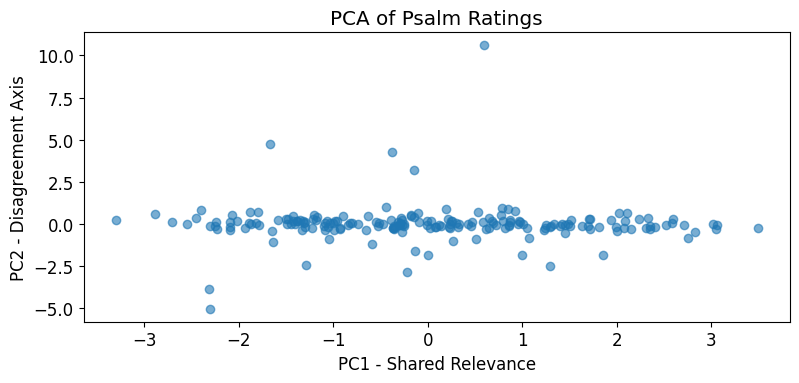

In [108]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})

plt.figure(figsize=(8,4))
plt.scatter(components[:,0], components[:,1], alpha=0.6)

plt.xlabel("PC1 - Shared Relevance")
plt.ylabel("PC2 - Disagreement Axis")
plt.title("PCA of Psalm Ratings")

plt.tight_layout()   # prevents labels from being cut off
plt.savefig('overall_pca.png')

plt.show()

In [109]:
# PC1 consensus score
df_clean["PC1_consensus"] = components[:, 0]

# Optional: rescale PC1 to 0–10 for interpretability
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler(feature_range=(0,10))
df_clean["PC1_rescaled"] = mm.fit_transform(
    df_clean[["PC1_consensus"]]
)

In [110]:
df_clean["rating_std"] = df_raters.apply(
    lambda row: np.nanstd(row),
    axis=1
)

In [111]:
# Top 10 most disagreed psalms
high_disagreement = df_clean.sort_values(
    "rating_std",
    ascending=False
).head(10)

print(high_disagreement[["PC1_rescaled", "rating_std"]])

User  PC1_rescaled  rating_std
36        4.336285    4.500000
169       6.403322    4.123106
78        3.393835    4.062019
62        4.310487    3.960745
6         3.129389    3.897114
176       4.655168    3.840573
54        5.609336    3.774917
143       3.444383    3.774917
164       3.775986    3.774917
193       3.895760    3.674235


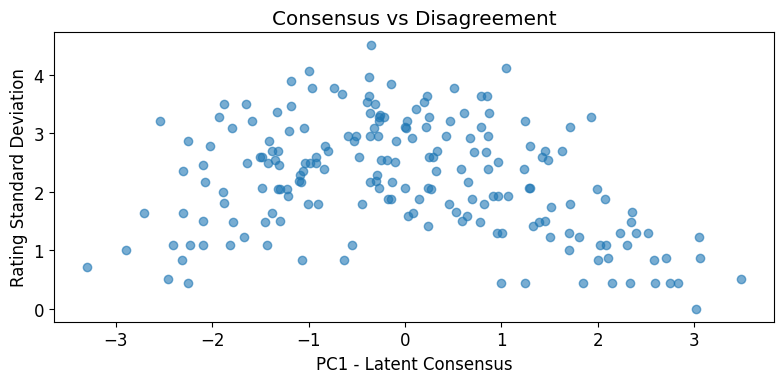

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(df_clean["PC1_consensus"],
            df_clean["rating_std"],
            alpha=0.6)

plt.xlabel("PC1 - Latent Consensus")
plt.ylabel("Rating Standard Deviation")
plt.title("Consensus vs Disagreement")

plt.tight_layout()   # adjust layout first
plt.savefig("consensus_disagreement_v2.png")

plt.show()

In [113]:
scores_piv

User,Query,Query Category,Method,Similarity Score (%),numbered_result,Text,Psalm Num,Verse,caden,p01,...,p04,p05,p06,p07,p08,p09,p10,p13,p16,p17
0,Create in me a clean heart,Phrase/Exact Match Queries,BERT,68.31,5,Bible,147,Alleluia of Aggeus and Zacharias Praise the Lo...,5.0,NaN,...,NaN,6.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,Create in me a clean heart,Phrase/Exact Match Queries,BERT,68.66,4,Psalter,43,"We have heard with our ears, O God, for our fa...",0.0,3.0,...,NaN,7.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Create in me a clean heart,Phrase/Exact Match Queries,BERT,68.69,3,Psalter,49,"The God of gods, even the Lord, hath spoken, a...",5.0,NaN,...,NaN,9.0,7.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN
3,Create in me a clean heart,Phrase/Exact Match Queries,BERT,69.06,2,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",8.0,NaN,...,NaN,NaN,5.0,NaN,7.0,NaN,4.0,NaN,NaN,NaN
4,Create in me a clean heart,Phrase/Exact Match Queries,BERT,69.89,1,Bible,18,For the End a psalm by David The heavens decla...,4.0,NaN,...,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,18.97,5,Bible,151,1This is a psalm written with Davids own hand ...,6.0,5.0,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,22.61,4,Psalter,28,"Bring unto the Lord, O ye sons of God, bring u...",3.0,NaN,...,NaN,NaN,1.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
192,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,23.85,3,Psalter,86,His foundations are in the holy mountains. The...,4.0,NaN,...,5.0,NaN,0.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
193,protection from enemies,Thematic/Semantic Queries,TFIDF_GLoVe,25.01,2,Bible,28,A psalm by David the final day of the Feast of...,9.0,3.0,...,NaN,NaN,0.0,NaN,8.0,NaN,NaN,NaN,NaN,NaN


In [114]:
df_clean

User,caden,p01,p02,p03,p04,p05,p06,p07,p08,p09,p10,p13,p16,p17,PC1_consensus,PC1_rescaled,rating_std
0,5.0,NaN,NaN,0.0,NaN,6.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,-2.022418,1.886198,2.772634
1,0.0,3.0,NaN,NaN,NaN,7.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.488201,2.672567,2.586020
2,5.0,NaN,NaN,NaN,NaN,9.0,7.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN,0.918386,6.215068,1.920286
3,8.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,7.0,NaN,4.0,NaN,NaN,NaN,0.647703,5.816623,1.581139
4,4.0,NaN,8.0,1.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.421900,5.484240,2.947457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,6.0,5.0,9.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.088808,4.732476,2.861381
191,3.0,NaN,NaN,NaN,NaN,NaN,1.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN,-0.926622,3.499213,2.598076
192,4.0,NaN,NaN,NaN,5.0,NaN,0.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN,-1.482098,2.681551,2.061553
193,9.0,3.0,NaN,NaN,NaN,NaN,0.0,NaN,8.0,NaN,NaN,NaN,NaN,NaN,-0.657229,3.895760,3.674235


In [115]:
full = pd.concat([scores_piv, df_clean], axis=1)

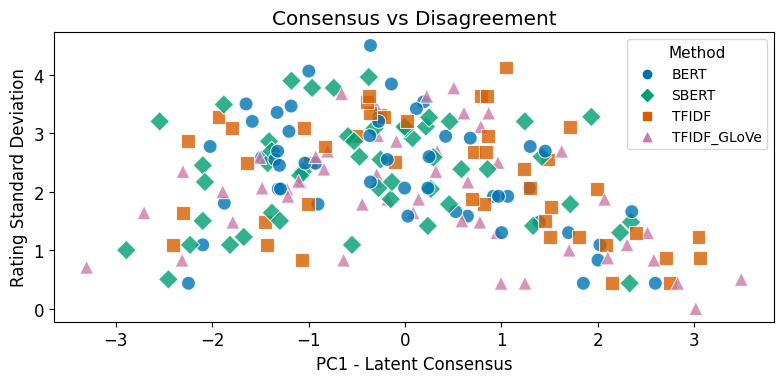

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a color-blind-friendly palette
color_blind_palette = {
    "BERT": "#0072B2",      # blue
    "TFIDF": "#D55E00",     # vermillion
    "SBERT": "#009E73",     # green
    "TFIDF_GLoVe": "#CC79A7"  # pink/magenta
}

# Optional: define marker shapes
markers = {
    "BERT": "o",        # circle
    "TFIDF": "s",       # square
    "SBERT": "D",       # diamond
    "TFIDF_GLoVe": "^"  # triangle
}

plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=full,
    x="PC1_consensus",
    y="rating_std",
    hue="Method",
    style="Method",          # shape by method
    palette=color_blind_palette,
    markers=markers,         # custom shapes
    alpha=0.8,
    s=100
)
plt.xlabel("PC1 - Latent Consensus")
plt.ylabel("Rating Standard Deviation")
plt.title("Consensus vs Disagreement")

plt.legend(title="Method", fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.savefig("consensus_disagreement-colored-shaped.png", dpi=300)
plt.show()

## Overall Score
- Low α ≈ random noise around PC1, not systematic rater conflict
- `PC1` -> reveals that there is a high overall consensus based on the far spread on the access
- `PC2` -> mainly hovering around zero.
    - unsystemic disagreement rather than systematic disagreement mainly casued by diffierent rater's 'style'
    - showing littler actualy noise


### Applying Query Categories

    
We are going to be adding these query categories to the data itself before begining analysis. Building in this categorical variable, there is a further breakdown that can be done inorder to find results and conclusions.

In [117]:
QUERY_TO_CATEGORY = {
    "mercy": "Simple Keyword Queries",
    "prayer": "Simple Keyword Queries",    
    "The Lord is my shepherd": "Phrase/Exact Match Queries",
    "Create in me a clean heart": "Phrase/Exact Match Queries",
    "protection from enemies": "Thematic/Semantic Queries",
    "praise in times of suffering": "Thematic/Semantic Queries",
    "How does the psalmist express trust in God while surrounded by fear and uncertainty?":
        "Long/Complex Queries",
    "Verses where the psalmist remembers past deliverance and uses it to find hope in present trials.":
        "Long/Complex Queries",
    "Rejoice, O ye heavens, sound the trumpets, ye foundation of the earth, thunder forth gladness, O ye mountains: for behold, Emanuel to the Cross our sins, and the Giver of Life hath slain death, raising up Adam; for He loveth mankind.":
        "Orthodox Service Quotes",
    "Have mercy on me, O God, have mercy on me. For my soul trusts in Thee, and in the shadow of Thy wings will I hope, until iniquity pass away.":
        "Orthodox Service Quotes",
    "For the Peace of the world": "Orthodox Service Quotes"
}

In [118]:
scores["Query Category"] = scores["Query"].map(QUERY_TO_CATEGORY)
scores

,Query,Query Category,Method,Similarity Score (%),numbered_result,Text,Psalm Num,Verse,User,Score
0,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,26.10,1,Psalter,100,I will sing of mercy and judgment unto Thee O ...,caden,9
1,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,25.67,2,Bible,4,For the End in psalms an ode by David You hear...,caden,6
2,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,21.90,3,Bible,31,By David concerning understanding Blessed are ...,caden,3
3,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.33,4,Psalter,31,Blessed are they whose iniquities are forgiven...,caden,10
4,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.12,5,Bible,61,For the End for Jeduthun a psalm by David Shal...,caden,7
...,...,...,...,...,...,...,...,...,...,...
944,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,5.61,5,Psalter,35,"The transgressor, that he may sin, saith withi...",p05,7
945,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,5.61,5,Psalter,35,"The transgressor, that he may sin, saith withi...",p06,2
961,,NaN,,,5,,,,,5
962,,NaN,,,5,,,,,5


In [119]:
scores.head()

,Query,Query Category,Method,Similarity Score (%),numbered_result,Text,Psalm Num,Verse,User,Score
0,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,26.10,1,Psalter,100,I will sing of mercy and judgment unto Thee O ...,caden,9
1,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,25.67,2,Bible,4,For the End in psalms an ode by David You hear...,caden,6
2,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,21.90,3,Bible,31,By David concerning understanding Blessed are ...,caden,3
3,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.33,4,Psalter,31,Blessed are they whose iniquities are forgiven...,caden,10
4,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.12,5,Bible,61,For the End for Jeduthun a psalm by David Shal...,caden,7


In [120]:
scores = scores[scores["Query"] != '']

with_caden = scores
without_caden = scores[scores['User'] == 'caden']

In [121]:
pd.pivot_table(scores, index=["Method"], values="Score", aggfunc='mean')
pd.pivot_table(without_caden, index=["Method"], values="Score", aggfunc='mean')

,Score
Method,
BERT,6.363636
SBERT,4.890909
TFIDF,6.240000
TFIDF_GLoVe,6.472727


In [122]:
pd.pivot_table(without_caden, index=["Method"], values="Score", aggfunc='mean')


,Score
Method,
BERT,6.363636
SBERT,4.890909
TFIDF,6.240000
TFIDF_GLoVe,6.472727


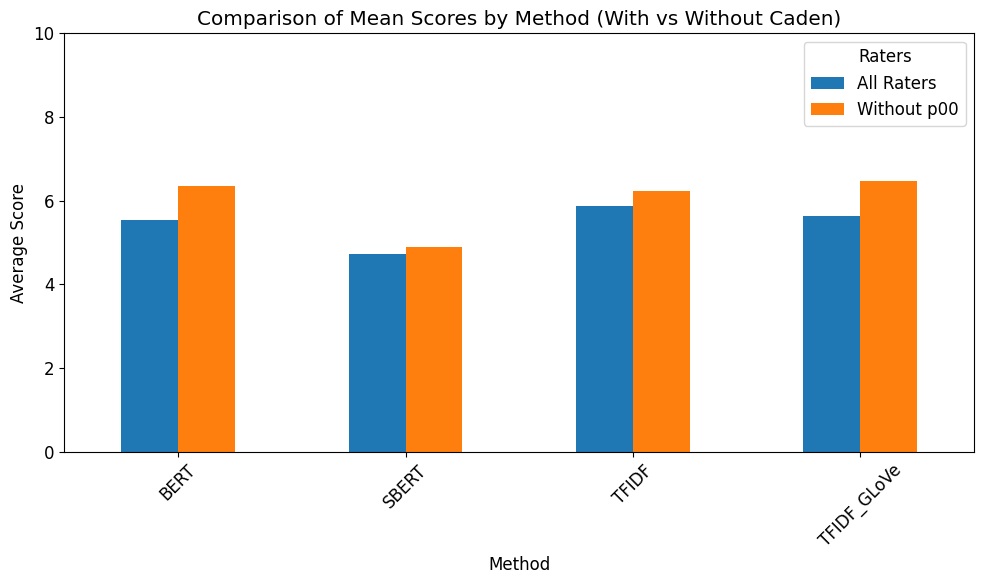

In [123]:
import pandas as pd
import matplotlib.pyplot as plt

# Pivot tables
all_mean = pd.pivot_table(scores, index="Method", values="Score", aggfunc='mean')
without_caden_mean = pd.pivot_table(without_caden, index="Method", values="Score", aggfunc='mean')

# Combine into one DataFrame for easier plotting
compare_df = pd.concat([all_mean, without_caden_mean], axis=1)
compare_df.columns = ['All Raters', 'Without p00']

# Plot
ax = compare_df.plot(kind='bar', figsize=(10,6))
ax.set_ylabel("Average Score")
ax.set_title("Comparison of Mean Scores by Method (With vs Without Caden)")
plt.xticks(rotation=45)
plt.ylim(0,10)  # assuming scores are 0-10
plt.legend(title="Raters")
plt.tight_layout()
plt.show()

In [124]:
pd.pivot_table(scores, index=["Method"], values="Score", aggfunc='mean')

,Score
Method,
BERT,5.536364
SBERT,4.718182
TFIDF,5.870000
TFIDF_GLoVe,5.627273


In [125]:
pd.pivot_table(scores, index=["Method", "Query Category"], values="Score", aggfunc='mean')

Score
Method      Query Category                   
BERT        Long/Complex Queries        6.150
            Orthodox Service Quotes     5.250
            Phrase/Exact Match Queries  4.925
            Simple Keyword Queries      5.400
            Thematic/Semantic Queries   5.900
SBERT       Long/Complex Queries        5.800
            Orthodox Service Quotes     4.400
            Phrase/Exact Match Queries  3.400
            Simple Keyword Queries      4.750
            Thematic/Semantic Queries   5.450
TFIDF       Long/Complex Queries        5.275
            Orthodox Service Quotes     7.050
            Phrase/Exact Match Queries  6.425
            Simple Keyword Queries      7.000
            Thematic/Semantic Queries   4.450
TFIDF_GLoVe Long/Complex Queries        4.675
            Orthodox Service Quotes     5.975
            Phrase/Exact Match Queries  4.275
            Simple Keyword Queries      8.100
            Thematic/Semantic Queries   5.075

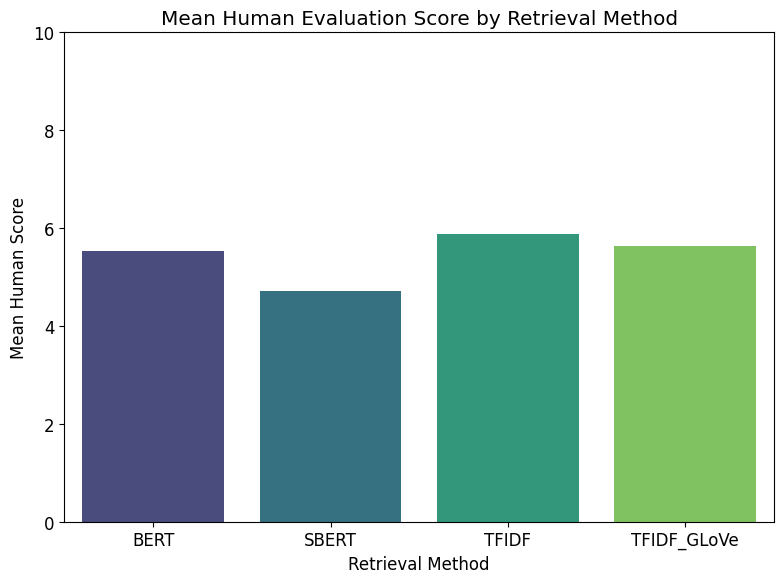

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mean score per method
pivot = pd.pivot_table(
    scores,
    index="Method",
    values="Score",
    aggfunc="mean"
).reset_index()

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=pivot,
    x="Method",
    y="Score",
    palette="viridis"
)

plt.xlabel("Retrieval Method")
plt.ylabel("Mean Human Score")
plt.ylim(0,10)  # assuming scores are 0-10
plt.title("Mean Human Evaluation Score by Retrieval Method")

plt.tight_layout()
plt.show()

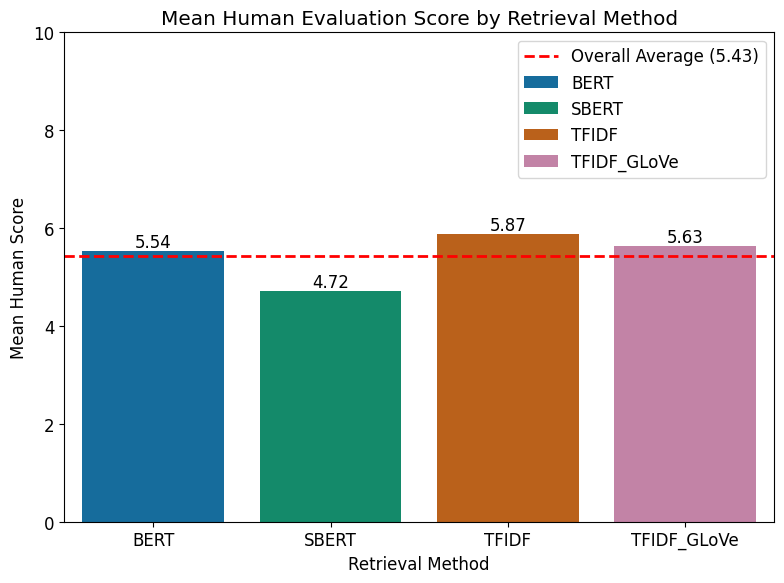

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mean score per method
pivot = pd.pivot_table(
    scores,
    index="Method",
    values="Score",
    aggfunc="mean"
).reset_index()

# Overall average score
overall_avg = scores["Score"].mean()

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=pivot,
    x="Method",
    y="Score",
    hue="Method",
    dodge=False, 
    palette=color_blind_palette,
)

# Add horizontal average line
plt.axhline(overall_avg, linestyle="--", color='red', linewidth=2, label=f"Overall Average ({overall_avg:.2f})")

# Label bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.xlabel("Retrieval Method")
plt.ylabel("Mean Human Score")
plt.title("Mean Human Evaluation Score by Retrieval Method")
plt.ylim(0,10)

plt.legend()
plt.tight_layout()
plt.savefig('algorithm_avgs.png')
plt.show()

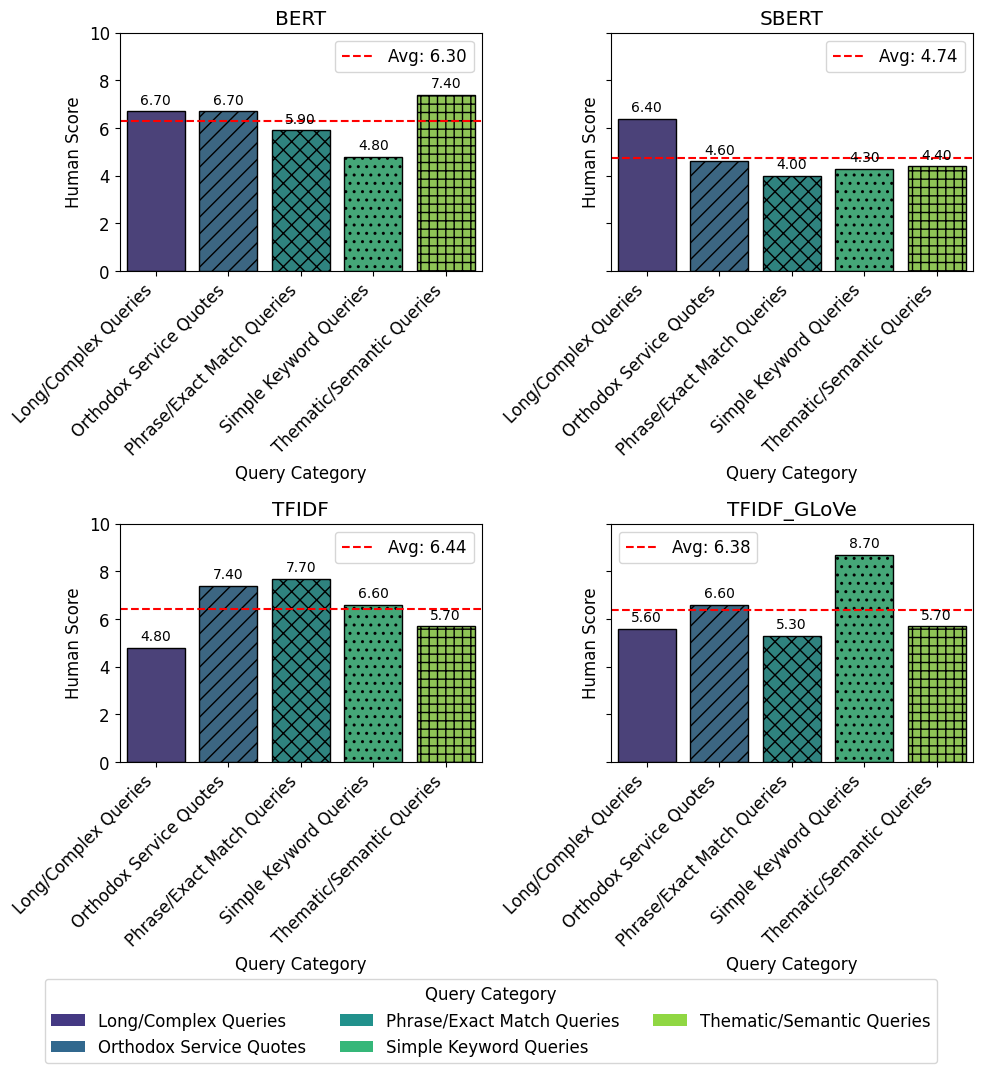

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.patches import Patch

# Pivot table
pivot = pd.pivot_table(
    without_caden,
    index=["Method", "Query Category"],
    values="Score",
    aggfunc="mean"
).reset_index()

methods = pivot["Method"].unique()
categories = pivot["Query Category"].unique()

# Color-blind friendly palette
palette = sns.color_palette("viridis", len(categories))
color_map = dict(zip(categories, palette))

# Texture patterns (hatching)
hatches = ["", "//", "xx", "..", "++", "\\\\", "--"]
hatch_map = dict(zip(categories, hatches))

# Determine subplot layout
n_methods = len(methods)
n_rows = 2
n_cols = math.ceil(n_methods / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows), sharey=True)
axes = axes.flatten()

y_min = 0
y_max = 10

for ax, method in zip(axes, methods):

    subset = pivot[pivot["Method"] == method]

    sns.barplot(
        data=subset,
        x="Query Category",
        y="Score",
        palette=color_map,
        edgecolor="black",
        ax=ax
    )

    # Apply texture to bars
    for bar, category in zip(ax.patches, subset["Query Category"]):
        bar.set_hatch(hatch_map[category])

    # Add labels to bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10)

    # Compute method average
    method_avg = subset["Score"].mean()

    ax.axhline(method_avg, color="red", linestyle="--", label=f"Avg: {method_avg:.2f}")
    ax.legend()

    ax.set_title(method)
    ax.set_xlabel("Query Category")
    ax.set_ylabel("Human Score")
    ax.set_ylim(y_min, y_max)

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right"
    )

# Turn off empty axes
for ax in axes[n_methods:]:
    ax.axis("off")
legend_handles = [Patch(facecolor=color_map[c], label=c) for c in categories]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,  # forces wrapping into two rows
    title="Query Category",
    bbox_to_anchor=(0.5, -0.08)
)
legend_fig = plt.figure(figsize=(8, 2))

legend_fig.legend(
    handles=legend_handles,
    loc="center",
    ncol=3,
    title="Query Category",
    frameon=False
)

legend_fig.savefig("query_category_legend.png", bbox_inches="tight", dpi=300)
plt.close(legend_fig)
plt.tight_layout()
plt.savefig("method_cats_sepLegend.png")
plt.show()

/opt/conda/lib/python3.11/site-packages/matplot2tikz/_path.py:502: UserWarning: matplot2tikz: The hatch  is ignored.
  pattern = _mpl_hatch2pgfp_pattern(data, line_data.hatch, h_col, h_rgba)
/opt/conda/lib/python3.11/site-packages/matplot2tikz/_hatches.py:70: UserWarning: matplot2tikz: Hatch '//' cannot be rendered. Only single character hatches are supported, e.g., {'/', '\', '|', '-', '+', 'x', 'o', 'O', '.', '*'}. Hatch '/' will be used.
  hatch = __validate_hatch(hatch)
/opt/conda/lib/python3.11/site-packages/matplot2tikz/_hatches.py:70: UserWarning: matplot2tikz: Hatch 'xx' cannot be rendered. Only single character hatches are supported, e.g., {'/', '\', '|', '-', '+', 'x', 'o', 'O', '.', '*'}. Hatch 'x' will be used.
  hatch = __validate_hatch(hatch)
/opt/conda/lib/python3.11/site-packages/matplot2tikz/_hatches.py:70: UserWarning: matplot2tikz: Hatch '..' cannot be rendered. Only single character hatches are supported, e.g., {'/', '\', '|', '-', '+', 'x', 'o', 'O', '.', '*'}. Hat

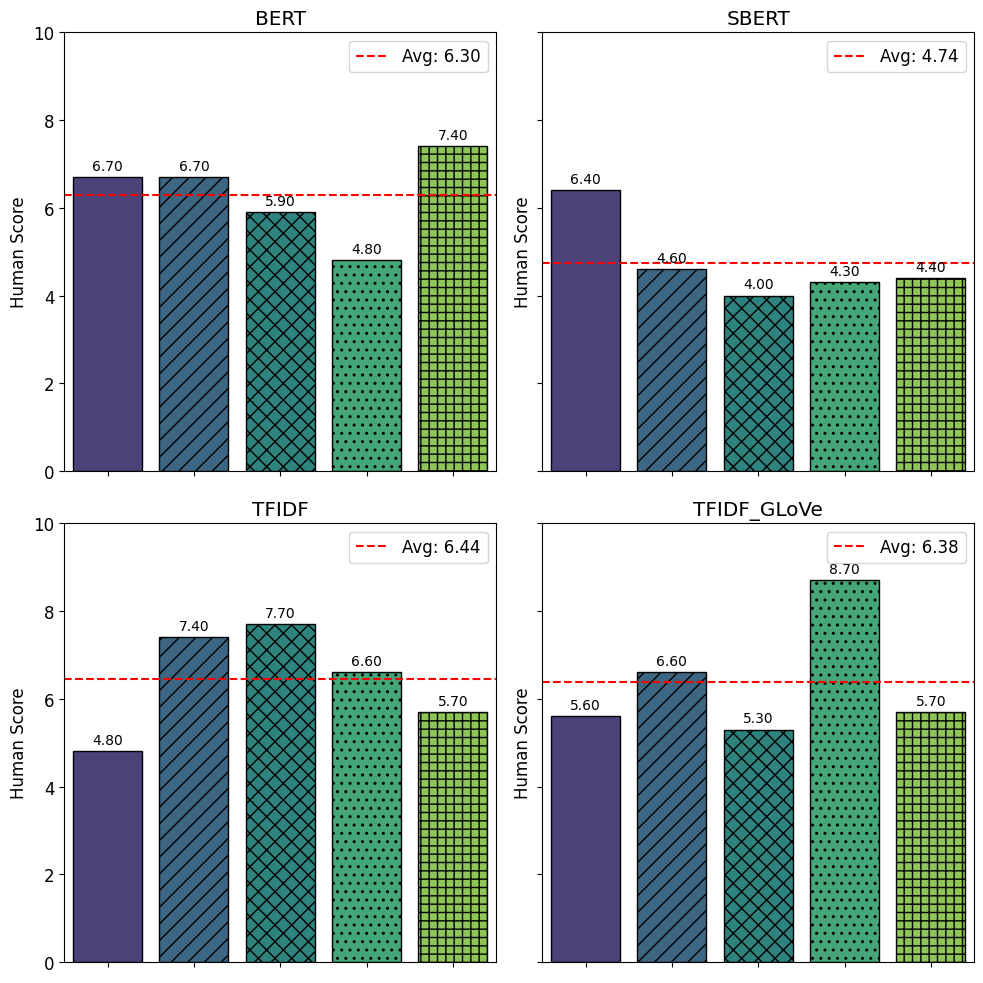

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.patches import Patch

# Pivot table: mean score per method x category
pivot = pd.pivot_table(
    without_caden,
    index=["Method", "Query Category"],
    values="Score",
    aggfunc='mean'
).reset_index()

methods = pivot['Method'].unique()
categories = pivot['Query Category'].unique()

# Color-blind-friendly palette
palette = sns.color_palette("viridis", len(categories))
color_map = dict(zip(categories, palette))

# Hatch patterns for texture
hatches = ["", "//", "xx", "..", "++", "\\\\", "--"]
hatch_map = dict(zip(categories, hatches))

# Layout of subplots
n_methods = len(methods)
n_rows = 2
n_cols = math.ceil(n_methods / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows), sharey=True)
axes = axes.flatten()

y_min, y_max = 0, 10

for ax, method in zip(axes, methods):
    subset = pivot[pivot['Method'] == method]

    # Barplot with edgecolor for better hatching visibility
    sns.barplot(
        data=subset,
        x='Query Category',
        y='Score',
        palette=color_map,
        edgecolor='black',
        ax=ax
    )

    # Apply hatch patterns
    for bar, category in zip(ax.patches, subset['Query Category']):
        bar.set_hatch(hatch_map[category])

    # Add labels to bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10)

    # Method average line
    method_avg = subset['Score'].mean()
    ax.axhline(method_avg, color='red', linestyle='--', label=f"Avg: {method_avg:.2f}")
    ax.legend()

    ax.set_title(method)
    ax.set_xlabel("")          # remove x-axis label
    ax.set_ylabel("Human Score")
    ax.set_ylim(y_min, y_max)
    ax.set_xticklabels([])     # remove category labels

# Turn off unused axes
for ax in axes[n_methods:]:
    ax.axis('off')

# Separate legend for categories (color + texture)
legend_handles = [
    Patch(facecolor=color_map[c], edgecolor='black', hatch=hatch_map[c], label=c)
    for c in categories
]

legend_fig = plt.figure(figsize=(8, 2))
legend_fig.legend(
    handles=legend_handles,
    loc="center",
    ncol=3,
    title="Query Category",
    frameon=False
)
legend_fig.savefig("query_category_legend.png", bbox_inches="tight", dpi=300)
plt.close(legend_fig)

# Tight layout and save main figure
plt.tight_layout()
import matplot2tikz

matplot2tikz.save("figure.tex")
plt.show()

In [130]:
%pip install matplot2tikz

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Pivot table: mean score per method x category
pivot = pd.pivot_table(
    without_caden,
    index=["Method", "Query Category"],
    values="Score",
    aggfunc='mean'
).reset_index()

methods = pivot['Method'].unique()
categories = pivot['Query Category'].unique()

# Color-blind-friendly palette
palette = sns.color_palette("viridis", len(categories))
color_map = dict(zip(categories, palette))

# Hatch patterns for texture
hatches = ["", "//", "xx", "..", "++", "\\\\", "--"]
hatch_map = dict(zip(categories, hatches))

# Layout of subplots
n_methods = len(methods)
n_rows = 2
n_cols = math.ceil(n_methods / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows), sharey=True)
axes = axes.flatten()

y_min, y_max = 0, 10

for ax, method in zip(axes, methods):
    subset = pivot[pivot['Method'] == method]

    # Barplot with edgecolor for better hatching visibility
    sns.barplot(
        data=subset,
        x='Query Category',
        y='Score',
        palette=color_map,
        edgecolor='black',
        ax=ax
    )

    # Apply hatch patterns
    for bar, category in zip(ax.patches, subset['Query Category']):
        bar.set_hatch(hatch_map[category])

    # Add labels to bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10)

    # Method average line
    method_avg = subset['Score'].mean()
    ax.axhline(method_avg, color='red', linestyle='--', label=f"Avg: {method_avg:.2f}")
    ax.legend()

    ax.set_title(method, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("Human Score", fontsize=16)
    ax.set_ylim(y_min, y_max)
    ax.set_xticklabels([])     # remove category labels

# Turn off unused axes
for ax in axes[n_methods:]:
    ax.axis('off')

# -------------------------------
# Separate legend for Query Categories
# -------------------------------
legend_handles_category = [
    Patch(facecolor=color_map[c], edgecolor='black', hatch=hatch_map[c], label=c)
    for c in categories
]

legend_fig1 = plt.figure(figsize=(8, 2))
legend_fig1.legend(
    handles=legend_handles_category,
    loc="center",
    ncol=3,
    title="Query Category",
    frameon=False
)
legend_fig1.savefig("query_category_legend.png", bbox_inches="tight", dpi=300)
plt.close(legend_fig1)

# -------------------------------
# Separate legend for Method Averages
# -------------------------------
legend_handles_avg = [
    Line2D([0], [0], color='red', linestyle='--', label='Method Average')
]

legend_fig2 = plt.figure(figsize=(6, 2))
legend_fig2.legend(
    handles=legend_handles_avg,
    loc="center",
    ncol=1,
    title="Reference Line",
    frameon=False
)
legend_fig2.savefig("method_avg_legend.png", bbox_inches="tight", dpi=300)
plt.close(legend_fig2)

# -------------------------------
# Save main figure
# -------------------------------
plt.tight_layout()
plt.savefig("method_cats_sepLegend.png", dpi=300)
plt.show()

/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


NameError: name 'without_caden' is not defined

In [ ]:
%pip install tikzplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Prepare pivot tables
pivot_all = pd.pivot_table(
    scores,
    index=["Method", "Query Category"],
    values="Score",
    aggfunc='mean'
).reset_index()

pivot_no_caden = pd.pivot_table(
    without_caden,
    index=["Method", "Query Category"],
    values="Score",
    aggfunc='mean'
).reset_index()

# Unique methods
methods = pivot_all['Method'].unique()
n_methods = len(methods)

# Layout: 2 rows
n_rows = 2
n_cols = math.ceil(n_methods / n_rows)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows), sharey=True)
axes = axes.flatten()

# Y-axis limits
y_min = 0
y_max = 10  # assuming 0-10 scale

# Plot each method
for ax, method in zip(axes, methods):
    # Subsets
    subset_all = pivot_all[pivot_all['Method'] == method]
    subset_no_caden = pivot_no_caden[pivot_no_caden['Method'] == method]
    
    # Bar width offset
    width = 0.4
    x = range(len(subset_all))
    
    # Plot bars side by side
    ax.bar([i - width/2 for i in x], subset_all['Score'], width=width, label='All Raters', color='skyblue')
    ax.bar([i + width/2 for i in x], subset_no_caden['Score'], width=width, label='Without Caden', color='salmon')
    
    # Add average lines
    avg_all = subset_all['Score'].mean()
    avg_no_caden = subset_no_caden['Score'].mean()
    ax.axhline(avg_all, color='blue', linestyle='--', label=f"All Avg: {avg_all:.2f}")
    ax.axhline(avg_no_caden, color='red', linestyle='--', label=f"No Caden Avg: {avg_no_caden:.2f}")
    
    # X-axis
    ax.set_xticks(range(len(subset_all)))
    ax.set_xticklabels(subset_all['Query Category'], rotation=45, ha='right')
    
    ax.set_title(method)
    ax.set_ylabel("Score")
    ax.set_ylim(y_min, y_max)
    ax.legend()

# Turn off unused axes
for ax in axes[n_methods:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

- 15/20 times the external score avewrage is higher without me. 
- I agree with the external score the most, on averge, under `SBERT`

In [ ]:
numbered = pd.pivot_table(scores, index=['Method', 'numbered_result'], values='Score', aggfunc='mean').reset_index()
numbered

In [ ]:
scores.head()

In [ ]:
pd.pivot_table(scores, index=['numbered_result'], values='Score', aggfunc=['mean', 'count'])

In [ ]:
import seaborn as sns

colors = sns.color_palette("colorblind", len(pivot))

ax = pivot.plot(
    x='numbered_result',
    y='mean_score',
    kind='bar',
    legend=False,
    color=colors
)

plt.xlabel("Result Rank")
plt.ylabel("Mean Score")
plt.title("Mean Human Score by Result Rank")
plt.ylim(0,10)

plt.tight_layout()
plt.savefig("rank_avg.png")
plt.show()

In [ ]:
pd.pivot_table(data=numbered, index='numbered_result', values='Score', aggfunc=['mean', 'count'])

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=numbered,
    x='numbered_result',
    y='Score'
)

# Bigger axis labels
plt.xlabel("Result Number", fontsize=16)
plt.ylabel("Human Score", fontsize=16)

# Main title (slightly smaller than subtitle if desired)
plt.title("1 being the best; 5 being the 5th best", fontsize=14)

# Subtitle (larger, on top)
plt.suptitle("Mean Human Score by Result Number", fontsize=18, y=1.02)

# Optional: make tick labels bigger
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle

# Save figure
plt.savefig('ranks_averages_thickBars.png', dpi=300, bbox_inches='tight')
plt.show()


From this graph, it looks as though the *4th* best results seems to have the best over blind score out of all of the data. This is very surprising. Lets breack the graph down further to each how each method does as well. 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(12, 8))
sns.barplot(
    data=numbered,
    x='numbered_result',
    y='Score',
    hue="Method",
    dodge=True, 
    palette=color_blind_palette
)

plt.xlabel("Result Number", fontsize=18)
plt.ylabel("Score", fontsize=18)

# Main title
plt.title("1 being the best & 5 being the 5th best", fontsize=12)

# Subtitle
plt.suptitle("Mean Human Score by Result Number", fontsize=18, y=0.95)

plt.legend(title="Method", loc='lower right')

plt.savefig('rank_with_method.png')
plt.show()


In [ ]:
numbered_sorted = numbered.sort_values(by=['Method', 'Score'], ascending=[False, False])
numbered_sorted

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=numbered_sorted,
    x='Method',
    y='Score',
    hue='numbered_result',  # optional
    palette='viridis',
    errorbar=None,
)

plt.xlabel("Method")
plt.ylabel("Score")
plt.title("1 being the best & 5 being the 5th best", fontsize=12)
plt.suptitle("Mean Human Score by Result Number", fontsize=18, y=0.95)
plt.legend(title="Method", loc='upper right')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure 'numbered_result' is treated as a string/categorical
numbered_sorted['numbered_result'] = numbered_sorted['numbered_result'].astype(str)

# Create a new column combining Method and Result for ordering
numbered_sorted['Method_Result'] = numbered_sorted['Method'] + "_R" + numbered_sorted['numbered_result']

# Sort the dataframe by Method and Score descending
numbered_sorted = numbered_sorted.sort_values(by=['Method', 'Score'], ascending=[True, False])

# Make 'Method_Result' a categorical with this specific order
numbered_sorted['Method_Result'] = pd.Categorical(
    numbered_sorted['Method_Result'],
    categories=numbered_sorted['Method_Result'],
    ordered=True
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=numbered_sorted,
    x='Score',
    y='Method_Result',
    hue='numbered_result',
    palette='viridis',
    dodge=False,  # disable dodge because we're already encoding Result in x
    errorbar=None
)

plt.xlabel("Method & Result Number")
plt.ylabel("Score")
plt.title("1 being the best & 5 being the 5th best", fontsize=12)
plt.suptitle("Mean Human Score by Result Number", fontsize=18)
plt.show()

In [ ]:
import pandas as pd

# Sort by Method and Score descending
numbered_sorted = numbered.sort_values(by=['Method', 'Score'], ascending=[True, False]).copy()

# Add a new column 'rank_within_method'
numbered_sorted['rank_within_method'] = numbered_sorted.groupby('Method')['Score'] \
                                                     .rank(method='first', ascending=False) \
                                                     .astype(int)

print(numbered_sorted[['Method', 'Score', 'rank_within_method']])

In [ ]:
numbered_sorted

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Unique results and palette for coloring points
unique_results = sorted(numbered_sorted['numbered_result'].unique())
point_palette = sns.color_palette("tab10", n_colors=len(unique_results))
point_color_map = dict(zip(unique_results, point_palette))

# Custom line colors (color-blind friendly)
color_blind_palette = {
    "BERT": "#0072B2",       # blue
    "TFIDF": "#D55E00",      # vermillion
    "SBERT": "#009E73",      # green
    "TFIDF_GLoVe": "#CC79A7" # pink/magenta
}

methods = numbered_sorted['Method'].unique()
line_styles = ['-', '--', '-.', ':']  # different line styles

lines_for_legend = []
points_for_legend = []

for i, method in enumerate(methods):
    method_df = numbered_sorted[numbered_sorted['Method'] == method].sort_values('rank_within_method')
    
    # Use your custom color
    line_color = color_blind_palette[method]
    linestyle = line_styles[i % len(line_styles)]
    
    # Line connecting points
    line, = plt.plot(method_df['rank_within_method'], method_df['Score'],
                     linestyle=linestyle, alpha=0.8, color=line_color, linewidth=2.5, label=method)
    lines_for_legend.append(line)
    
    # Scatter points colored by numbered_result
    for j, row in method_df.iterrows():
        plt.scatter(row['rank_within_method'], row['Score'],
                    color=point_color_map[row['numbered_result']], s=100)

# Create dummy scatter points for color legend
points_for_legend = [plt.Line2D([0], [0], marker='o', color='w', label=f'Original # {num}',
                                 markerfacecolor=point_color_map[num], markersize=10)
                     for num in unique_results]

plt.xlabel("Rebalanced Rank (1 = Best)", fontsize=18)
plt.ylabel("Score", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Rebalance Effect: Original Numbered Results vs New Ranks")
plt.xticks(sorted(numbered_sorted['rank_within_method'].unique()))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Legends: lines for Method, points for numbered_result
legend1 = plt.legend(handles=lines_for_legend, title="Method", loc='lower left')
plt.gca().add_artist(legend1)
plt.legend(handles=points_for_legend, title="Original Numbered Result", loc='upper right')

# Save figure
plt.savefig("rebalance_plot.png", dpi=300, bbox_inches='tight')
# plt.savefig("rebalance_plot.pdf", bbox_inches='tight')

plt.show()

In [ ]:
import pandas as pd

# Example: assuming your data is in a DataFrame called df
# Columns: Method, numbered_result, Score, rank_within_method, Method_rank

# Pivot to wide format
wide_df = numbered_sorted.pivot(index='Method', columns='rank_within_method', values='numbered_result')

# Optional: rename columns to R1, R2, ...
wide_df.columns = [f'R{int(c)}' for c in wide_df.columns]

# Reset index to make Method a column
wide_df = wide_df.reset_index()

wide_df

In [ ]:
scores

In [ ]:
pivot_1 = pd.pivot_table(data=scores, index=['Query Category', 'Method'], values=['Score'], aggfunc='mean')
pivot_1

In [ ]:
import pandas as pd

# Your pivot table
pivot_1 = pd.pivot_table(
    data=scores,
    index=['Query Category', 'Method'],
    values='Score',
    aggfunc='mean'
).reset_index()

# Find the method with max mean per category
max_per_category = pivot_1.loc[pivot_1.groupby('Query Category')['Score'].idxmax()]

max_per_category

In [ ]:
# })

# Merge the extra info into max_per_category
merged = max_per_category.merge(wide_df, on='Method', how='left')

merged